<div align="center">

# Notebook 13 — Scalogramme CWT + R-Net (Wu, 2020) + WavLM Base-Plus (+ Pantagruel / résidu vocodeur en option)

# Classification multi-classes FOCH

**Fusion quadri-branche configurable — encodeurs de parole gelés + résidu vocodeur log-mel + R-Net entraîné from scratch sur l'attaque du scalogramme CWT**

![Python](https://img.shields.io/badge/Python-3.12-blue?style=flat-square&logo=python)
![PyTorch](https://img.shields.io/badge/PyTorch-2.11-EE4C2C?style=flat-square&logo=pytorch)
![HuggingFace](https://img.shields.io/badge/🤗-Transformers-FFD21F?style=flat-square)
![CUDA](https://img.shields.io/badge/CUDA-AMP%20Enabled-76B900?style=flat-square&logo=nvidia)
![Vocos](https://img.shields.io/badge/Vocos-r%C3%A9sidu%20vocodeur-8A2BE2?style=flat-square)
![PyWavelets](https://img.shields.io/badge/PyWavelets-CWT%20scalogramme-1f77b4?style=flat-square)
![R-Net](https://img.shields.io/badge/R--Net-Wu%202020-orange?style=flat-square)

</div>


## Synthèse de l'architecture quadri-branche

Ce notebook conserve intégralement le protocole d'évaluation du template (`StratifiedKFold` à 5 plis, déduplication patient, augmentation injectée dans le seul train, `FocalLoss` pondérée par pli) et n'en change que la **partie représentation** — exactement comme `10_0_foch_test_pantagruel.ipynb`, `11_0_foch_test_cwt_dinov2.ipynb` et `12_0_foch_test_cwt_resnet.ipynb` avant lui. Quatre branches, toutes activables indépendamment via le preset `BACKBONE` (Cellule 1) :

| Branche | Modèle / source | Entraînable ? | Sortie |
|---|---|---|---|
| **A — WavLM Base-Plus** | `microsoft/wavlm-base-plus`, répertoire local | **gelée** | moyenne temporelle du `last_hidden_state` → 768-d |
| **B — Pantagruel `speech-large-14K`** | dépôt local `speech-large-14K` (`trust_remote_code=True`) | **gelée** | moyenne temporelle du `last_hidden_state` → dimension **résolue à l'exécution** |
| **C — Résidu vocodeur (Vocos)** | `charactr/vocos-mel-24khz`, répertoire local, inférence CPU | **gelé** — seule la projection est apprise | 6 statistiques log-mel → `RESIDUAL_PROJ_DIM`-d après `Linear → ReLU` |
| **D — Scalogramme CWT → R-Net** *(cette variante)* | architecture custom **Wu (2020)**, initialisée aléatoirement | **ENTRAÎNABLE, from scratch** | vecteur pooled (`RNET_EMB_DIM`-d, 150 par défaut) après retrait de la tête de classification |

**1 — Ce qui change par rapport à `12_0_foch_test_cwt_resnet.ipynb` : le backbone de la branche D, et lui seul.** `12_0` faisait porter la branche D par un **ResNet ImageNet gelé** (torchvision, transfert d'apprentissage visuel). Ce notebook la remplace par **R-Net**, l'architecture convolutive légère décrite par Huiyi Wu (2020) : 4 couches de convolutions **à stride, sans pooling** (30 → 50 → 100 → 150 filtres, noyau 4×4, stride 4×4), **entraînée from scratch** sur le corpus FOCH/SVD plutôt que réutilisée depuis un pré-entraînement ImageNet. Le pipeline CWT (Cellule 4), le protocole de validation croisée (Cellule 5/7), le suivi de métriques (Cellule 8) et le journal de runs (Cellule 8b, repris de `10_0_foch_test_pantagruel.ipynb`) restent structurellement identiques.

**2 — Pourquoi from scratch plutôt que gelé.** R-Net n'a pas de checkpoint pré-entraîné disponible (ni sur ImageNet, ni sur un corpus audio) : contrairement au ResNet ou à DINOv2-Large des deux variantes précédentes, il n'y a rien à geler. C'est un pari inverse à `11_0`/`12_0` : plutôt que de transférer une représentation apprise sur des images naturelles vers un scalogramme, on entraîne une architecture minimaliste **directement** sur nos ~300 échantillons, en misant sur sa faible capacité (~346 k paramètres, cf. Cellule 6) pour limiter le surapprentissage.

**3 — Pourquoi une fenêtre d'attaque de 120 ms à 25 kHz, plutôt que les 4 s à 16 kHz partagés par les autres branches.** C'est la spécification de Wu (2020), reprise telle quelle : R-Net a été conçu pour analyser un scalogramme CWT de la **portion d'attaque** (onset) d'une voyelle soutenue — 3 000 échantillons à 25 kHz — pas l'enregistrement entier. La Cellule 4 détaille comment cette fenêtre est extraite de la même lecture disque que les autres branches, sans second accès fichier.

**4 — Pourquoi la CWT plutôt qu'un spectrogramme STFT/mel (inchangé depuis les variantes ViT/ResNet).** La CWT donne une résolution fréquentielle **logarithmique** — fine en basses fréquences (F0, périodicité jitter/shimmer), plus grossière en aigu — a priori mieux adaptée aux irrégularités de phonation que la résolution linéaire d'un spectrogramme STFT classique.

**5 — Pourquoi conserver les branches A/B/C à côté.** Comme dans les trois notebooks précédents, les branches ne sont pas supposées redondantes *a priori*. Le système de presets (Cellule 1) permet de les combiner ou de les isoler : `wavlm_bp_cwt_rnet` (préset par défaut de ce notebook) jusqu'à `pantagruel_wavlm_bp_residual_cwt_rnet` (les quatre branches), en passant par des ablations solo.

**6 — Portée du fine-tuning : la tête ET R-Net, pas les trois encodeurs profonds.** WavLM et Pantagruel restent **intégralement gelés**, sans exception ni dégel tardif — même contrainte que les notebooks précédents. R-Net, lui, est **entièrement entraînable** : c'est la différence structurelle centrale de cette variante, qui se répercute sur l'optimiseur (Cellule 7 — deux groupes de paramètres à des taux d'apprentissage distincts) et sur les checkpoints (Cellule 6 — `trainable_state_dict` inclut désormais R-Net).

> Les justifications détaillées accompagnent chaque section (Cellules 1, 4, 4c, 6, 6b, 7).


## 1. Configuration de l'environnement et des chemins

Cette première section centralise les dépendances, les chemins **et la sélection des branches**. Le notebook met en œuvre un **classifieur quadri-branche configurable** évalué par **validation croisée stratifiée à 5 plis** (`StratifiedKFold`), avec **augmentation de données injectée pli par pli dans le seul jeu d'entraînement**.

**Classes retenues :**
<div align="center">

| Classe | Origine | Justification |
|---|---|---|
| `PR` | FOCH | Paralysie récurrentielle — pathologie majoritaire (support le plus élevé) |
| `LMB` | FOCH | Lésion de la muqueuse bénigne — support intermédiaire |
| `fuite glottique` | FOCH | Support le plus faible — classe minoritaire critique |
| `Healthy` | Saarbruecken (SVD) | Groupe contrôle — voyelle /a/ à hauteur habituelle |

</div>

La classe `Cancer` reste **exclue** (support insuffisant, n ≈ 26). Le déséquilibre des trois pathologies est compensé par des **signaux augmentés** injectés **exclusivement dans le train de chaque pli** ; le pli de validation reste strictement original.

### Sélection configurable des branches (`BACKBONE`)

Le drapeau `BACKBONE` sélectionne un preset ; le reste du notebook (Dataset, modèle, boucle) s'adapte automatiquement aux dimensions d'embedding — la dimension de fusion est toujours la **somme** des dimensions des branches actives.

<div align="center">

| Preset | WavLM Base-Plus | Pantagruel | Résidu vocodeur | CWT → R-Net | Fusion |
|---|---|---|---|---|---|
| `wavlm_bp_cwt_rnet` *(défaut de ce notebook)* | ✅ 768-d | — | — | ✅ 150-d | somme des deux |
| `pantagruel_wavlm_bp_residual_cwt_rnet` | ✅ 768-d | ✅ | ✅ `RESIDUAL_PROJ_DIM` | ✅ | somme des quatre |
| `pantagruel_wavlm_bp_cwt_rnet` | ✅ 768-d | ✅ | — | ✅ | somme des trois |
| `cwt_rnet_solo` | — | — | — | ✅ | dim. R-Net |
| `pantagruel_wavlm_bp_residual` | ✅ 768-d | ✅ | ✅ | — | somme des trois (hérité) |
| `pantagruel_wavlm_bp` | ✅ 768-d | ✅ | — | — | somme des deux |
| `pantagruel_solo` | — | ✅ | — | — | dim. Pantagruel |
| `wavlm_bp_solo` | ✅ 768-d | — | — | — | 768-d |
| `residual_solo` | — | — | ✅ | — | `RESIDUAL_PROJ_DIM` |
| `pantagruel_residual` / `wavlm_bp_residual` | selon | selon | ✅ | — | somme |

</div>

`wavlm_bp_cwt_rnet` est le préset **par défaut** de ce notebook — la combinaison explicitement demandée (WavLM Base-Plus + scalogramme CWT → R-Net). Les presets hérités des notebooks précédents (Pantagruel, résidu vocodeur) restent tous disponibles pour composer des ablations plus larges, y compris le preset complet à quatre branches.

> 🔌 **Chargement strictement local — plus aucune dépendance réseau pour la branche D.** WavLM, Pantagruel et Vocos sont chargés depuis des répertoires locaux avec `local_files_only=True` (aucun accès à `huggingface.co`). **R-Net n'a pas de poids pré-entraînés à charger du tout** : contrairement au ResNet de `12_0` (torchvision/`download.pytorch.org`) ou à DINOv2-Large de `11_0` (HuggingFace), il est initialisé aléatoirement (`torch.manual_seed`, Cellule 1) — aucun risque de blocage réseau sur cette branche.

> 📦 **Dépendances de ce notebook.** `pywt` (PyWavelets) pour la CWT, `matplotlib` pour la colormap du scalogramme — identique à `11_0`/`12_0`. **`torchvision` n'est plus nécessaire** : R-Net est un `nn.Module` PyTorch pur (Cellule 6), sans dépendance à une bibliothèque de modèles image pré-entraînés.

### Dimension d'embedding de Pantagruel — résolue, jamais supposée

⚠️ **Piège de configuration.** Le `config.json` de Pantagruel expose **deux** attributs de dimension contradictoires :

- `hidden_size = 768` — valeur héritée par défaut de `PretrainedConfig`, **jamais utilisée** par le graphe du modèle ;
- `embed_dim = 1024` — dimension réellement employée par toutes les couches (`modeling_pantagruel_uni.py` construit chaque bloc à partir de `config.embed_dim`).

Lire `config.hidden_size`, réflexe habituel avec les modèles HuggingFace, donnerait ici une dimension de fusion **fausse de 256**. La Cellule 1 résout donc la dimension via `_resolve_pantagruel_dim()` (priorité à `embed_dim`) et **signale explicitement** la divergence ; la Cellule 6 la **revérifie sur une passe avant réelle**.

### Dimension R-Net — une constante d'architecture, pas une valeur résolue depuis un checkpoint

Contrairement à `RESNET_EMB_DIM`/`RESNET_IMG_SIZE` dans `12_0` (lues depuis les métadonnées d'un checkpoint torchvision externe), `RNET_EMB_DIM` (= `RNET_CONV_CHANNELS[-1]`, 150 par défaut) est une **constante d'architecture** que nous choisissons nous-mêmes : il n'existe aucun checkpoint externe dont la dimension pourrait diverger silencieusement. La discipline « jamais écrit en dur sans vérification » se déplace donc ailleurs pour cette branche : c'est la **géométrie spatiale** de l'empilement de convolutions à stride qui doit être validée (`CWT_N_SCALES`/`ONSET_LEN` doivent rester assez grands pour survivre à 4 réductions consécutives par 4) — vérifiée par construction en Cellule 1, puis **revérifiée sur une passe avant réelle** en Cellule 6, exactement comme Pantagruel.

### Branche résidu vocodeur

`RESIDUAL_FEATURES` est une **liste fixe** de 6 statistiques dérivées du résidu log-mel Vocos (Cellule 4) : énergie globale, moyenne `|résidu|` par tiers de bandes mel (grave/médian/aigu), platitude spectrale, entropie temporelle. Elles sont projetées par un `Linear(N_RESIDUAL_FEATURES, RESIDUAL_PROJ_DIM) → ReLU`.

### Branche scalogramme CWT → R-Net

`CWT_WAVELET` (Morlet complexe — PyWavelets n'implémente pas d'ondelette de Morse analytique, l'option par défaut de `cwt` MATLAB ; cf. encadré Cellule 4), `CWT_FREQ_MIN`/`CWT_FREQ_MAX` (bande de fréquences log-espacée) et `CWT_N_SCALES` pilotent le calcul du scalogramme ; `ONSET_SR`/`ONSET_WINDOW_S` pilotent la fenêtre d'attaque (25 kHz, 120 ms, 3 000 échantillons — spécification Wu 2020) ; `RNET_CONV_CHANNELS`/`RNET_KERNEL`/`RNET_STRIDE` pilotent l'architecture R-Net elle-même. Aucune de ces valeurs n'est apprise par la branche D en amont du réseau (le scalogramme est un prétraitement déterministe) ; R-Net, lui, **est** entraîné — à la différence des deux variantes précédentes.

### Budget mémoire

WavLM et Pantagruel restent gelés et exécutés sous `torch.no_grad()` : aucune activation intermédiaire n'y est conservée. **R-Net, à l'inverse, participe pleinement à la rétropropagation** — mais son nombre de paramètres (~346 k, cf. Cellule 6) est minuscule comparé aux dizaines/centaines de millions de WavLM/Pantagruel, et ses activations (scalogramme 256×3000 réduit par stride, pas de skip-connections) restent légères. La **sonde VRAM (Cellule 6b)** reste à relancer après tout changement de preset ou d'hyperparamètre R-Net. Poids et métriques sont sauvegardés dans `.poids_modèles` et `.foch_métriques`.


In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 1 — Imports, configuration des chemins et hyperparamètres
# ═══════════════════════════════════════════════════════════════════════════
import os

# ── Mode strictement HORS LIGNE (Hugging Face) ───────────────────────────────
# Cette machine n'a pas accès à huggingface.co. Ces variables DOIVENT être
# posées AVANT l'import de `transformers` : la bibliothèque les lit au moment
# de son initialisation. Tous les modèles HuggingFace sont ensuite chargés
# depuis des répertoires locaux avec local_files_only=True.
os.environ['HF_HUB_OFFLINE']      = '1'
os.environ['TRANSFORMERS_OFFLINE'] = '1'

import gc
import glob
import random
import warnings

import numpy as np
import pandas as pd
import torch
import torchaudio
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')

# ── Reproductibilité ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── FFmpeg (backend de décodage audio pour torchaudio) ───────────────────────
import shutil
_ffmpeg_bin = r'C:/Users/AdminIA/Downloads/ffmpeg-8.1.1-full_build-shared/ffmpeg-8.1.1-full_build-shared/bin'
if os.path.isdir(_ffmpeg_bin):
    os.environ['PATH'] += os.pathsep + _ffmpeg_bin
print(f'FFmpeg : {shutil.which("ffmpeg")}')

# ── Chemins des données ──────────────────────────────────────────────────────
CSV_PATH        = r'C:\Users\AdminIA\Desktop\Classif_Aug\.df\.good_df\orl_df_vowel_master_updated_20260803.csv'
FOCH_AUDIO_DIR  = r'C:/Users/AdminIA/Desktop/ORL_IA_FOCH_Callum_HOLLIDAY/Segmented_Voyelles_Best'
SVD_HEALTHY_DIR = r'C:/Users/AdminIA/Documents/SVD/healthy'

# ── Données augmentées ────────────────────────────────────────────────────────
# Chaque manifeste ne contient qu'un seul type d'augmentation (colonne `aug_type`
# du CSV, vérifié) :
#   'signal' → SpecAugment sur STFT linéaire (specaug.ipynb) — même patient
#   'vc'     → Seed-VC (voice conversion) — timbre d'un AUTRE patient, même classe
# AUG_TYPES_ENABLED sélectionne lesquels sont effectivement injectés en train
# (Cellule 5). Retirer un type ici retire tout son volume du pool augmenté sans
# toucher aux manifestes ni aux fichiers .wav sur disque.
AUG_DIR         = r'C:/Users/AdminIA/Desktop/ORL_IA_FOCH_Callum_HOLLIDAY/Segmented_Voyelles_Augmented'
AUG_SIGNAL_DIR  = os.path.join(AUG_DIR, 'signal')
AUG_MANIFESTS   = {
    'signal': os.path.join(AUG_DIR, 'manifest_train_bal.csv'),
    'vc':     os.path.join(AUG_DIR, 'manifest_train_bal_vc.csv'),
}
AUG_TYPES_ENABLED = {'signal', 'vc'}   # sous-ensemble de AUG_MANIFESTS — set() = pas d'augmentation

# ═══════════════════════════════════════════════════════════════════════════
# SÉLECTION CONFIGURABLE DES BRANCHES  (cf. Cellule 6 pour le modèle)
# ═══════════════════════════════════════════════════════════════════════════
# Le classifieur est un réseau QUADRI-BRANCHE. Chaque branche est indépendante :
#   • WavLM Base-Plus (gelé)  — détail acoustique microscopique, anglais,
#     objectif de pré-entraînement « denoising / speaker mixing » ;
#   • Pantagruel speech-large-14K (gelé) — encodeur data2vec-2.0 pré-entraîné
#     sur ~14 000 h de parole FRANÇAISE, apparié à la langue du corpus FOCH ;
#   • Résidu vocodeur (Vocos, gelé) — écart, en domaine LOG-MEL, entre un
#     enregistrement et sa propre resynthèse par un vocodeur neuronal
#     pré-entraîné ; résumé par 6 statistiques et projeté vers
#     RESIDUAL_PROJ_DIM ;
#   • Scalogramme CWT → R-Net (ENTRAÎNABLE) — la fenêtre d'ATTAQUE de la forme
#     d'onde (120 ms, 25 kHz, spécification Wu 2020 — PAS l'enregistrement
#     entier utilisé par les 3 autres branches) est transformée en image
#     temps-fréquence (transformée en ondelettes continue, ondelette de
#     Morlet complexe) puis analysée par R-Net, un réseau convolutif LÉGER À
#     4 COUCHES STRIDÉES, initialisé aléatoirement et entraîné from scratch.
#     Remplace la branche ResNet ImageNet GELÉE de
#     `12_0_foch_test_cwt_resnet.ipynb` (elle-même un remplacement de la
#     variante Vision Transformer DINOv2-Large de
#     `11_0_foch_test_cwt_dinov2.ipynb`) — même position architecturale
#     (scalogramme → CNN), mais backbone entraîné plutôt que transféré.
#     Cf. Cellule 4 pour le calcul du scalogramme et Cellule 6 pour le modèle.
#
# On sélectionne un preset unique ; le Dataset, le modèle et la boucle
# d'entraînement s'adaptent automatiquement aux branches actives.
#
#   'wavlm_bp_cwt_rnet'                     → WavLM-BP + CWT→R-Net       [DÉFAUT]
#   'pantagruel_wavlm_bp_residual_cwt_rnet' → les QUATRE branches
#   'pantagruel_wavlm_bp_cwt_rnet'          → WavLM-BP + Pantagruel + CWT→R-Net
#   'cwt_rnet_solo'                         → CWT→R-Net seul             (ablation)
#   'pantagruel_wavlm_bp_residual'          → WavLM-BP + Pantagruel + résidu (sans CWT-CNN)
#   'pantagruel_wavlm_bp'                   → WavLM-BP + Pantagruel (sans résidu ni CWT-CNN)
#   'pantagruel_solo'                       → Pantagruel seul            (ablation)
#   'wavlm_bp_solo'                         → WavLM Base-Plus seul       (ablation)
#   'residual_solo'                         → résidu vocodeur seul       (ablation / référence)
#   'pantagruel_residual' / 'wavlm_bp_residual' → ablations croisées à deux branches
#
BACKBONE = 'cwt_rnet_solo'

_BACKBONE_PRESETS = {
    'wavlm_bp_cwt_rnet':                     {'wavlm': 'base_plus', 'pantagruel': False, 'residual': False, 'cwt_cnn': True},
    'pantagruel_wavlm_bp_residual_cwt_rnet': {'wavlm': 'base_plus', 'pantagruel': True,  'residual': True,  'cwt_cnn': True},
    'pantagruel_wavlm_bp_cwt_rnet':          {'wavlm': 'base_plus', 'pantagruel': True,  'residual': False, 'cwt_cnn': True},
    'cwt_rnet_solo':                         {'wavlm': None,        'pantagruel': False, 'residual': False, 'cwt_cnn': True},
    'pantagruel_wavlm_bp_residual':          {'wavlm': 'base_plus', 'pantagruel': True,  'residual': True,  'cwt_cnn': False},
    'pantagruel_wavlm_bp':                   {'wavlm': 'base_plus', 'pantagruel': True,  'residual': False, 'cwt_cnn': False},
    'pantagruel_solo':                       {'wavlm': None,        'pantagruel': True,  'residual': False, 'cwt_cnn': False},
    'wavlm_bp_solo':                         {'wavlm': 'base_plus', 'pantagruel': False, 'residual': False, 'cwt_cnn': False},
    'residual_solo':                         {'wavlm': None,        'pantagruel': False, 'residual': True,  'cwt_cnn': False},
    'pantagruel_residual':                   {'wavlm': None,        'pantagruel': True,  'residual': True,  'cwt_cnn': False},
    'wavlm_bp_residual':                     {'wavlm': 'base_plus', 'pantagruel': False, 'residual': True,  'cwt_cnn': False},
}
assert BACKBONE in _BACKBONE_PRESETS, f'BACKBONE inconnu : {BACKBONE} (choix : {list(_BACKBONE_PRESETS)})'
_preset        = _BACKBONE_PRESETS[BACKBONE]
WAVLM_VARIANT  = _preset['wavlm']         # 'base_plus' | 'base' | 'large' | None
USE_PANTAGRUEL = _preset['pantagruel']    # bool
USE_RESIDUAL   = _preset['residual']      # bool
USE_CWT_CNN    = _preset['cwt_cnn']       # bool

# ── Chemins locaux des backbones ─────────────────────────────────────────────
# ATTENTION : 'base_plus' (microsoft/wavlm-base-plus) est un CHECKPOINT DISTINCT
# de 'base' (microsoft/wavlm-base) — même architecture 12×768, poids différents
# (pré-entraînement 94 kh vs 960 h). Les trois répertoires coexistent sur disque ;
# seul 'base_plus' est référencé par les presets de ce notebook.
WAVLM_DIRS = {
    'base':      r'C:/Users/AdminIA/Documents/models/wavlm-base',
    'base_plus': r'C:/Users/AdminIA/Documents/models/wavlm-base-plus',
    'large':     r'C:/Users/AdminIA/Documents/models/wavlm-large',
}
PANTAGRUEL_DIR = r'C:/Users/AdminIA/Desktop/Classif_Aug/speech-large-14K'

WAVLM_DIR     = WAVLM_DIRS.get(WAVLM_VARIANT)      # None si la branche est inactive
WAVLM_EMB_DIM = {'base': 768, 'base_plus': 768, 'large': 1024, None: 0}[WAVLM_VARIANT]

if WAVLM_VARIANT is not None:
    assert os.path.isdir(WAVLM_DIR), f'Répertoire WavLM introuvable : {WAVLM_DIR}'
if USE_PANTAGRUEL:
    assert os.path.isdir(PANTAGRUEL_DIR), f'Répertoire Pantagruel introuvable : {PANTAGRUEL_DIR}'
    # Le code de modélisation distant doit être PRÉSENT localement : ce checkpoint
    # provient de Zenodo, pas du Hub, et rien ne peut être téléchargé ici.
    _pant_required = ['config.json', 'configuration_pantagruel_uni.py', 'modeling_pantagruel_uni.py']
    _pant_missing  = [f for f in _pant_required if not os.path.isfile(os.path.join(PANTAGRUEL_DIR, f))]
    assert not _pant_missing, (
        f'Code distant Pantagruel incomplet dans {PANTAGRUEL_DIR} : {_pant_missing} manquant(s). '
        "trust_remote_code=True ne peut PAS les récupérer (accès Hub coupé)."
    )

# ── Dimension d'embedding de Pantagruel — RÉSOLUE, jamais supposée ───────────
# Le config.json expose hidden_size=768 (valeur héritée par défaut de
# PretrainedConfig, INUTILISÉE par le graphe) et embed_dim=1024 (dimension
# réellement construite par modeling_pantagruel_uni.py). Lire hidden_size
# donnerait une dimension de fusion fausse de 256 → on privilégie embed_dim et
# on signale toute divergence. La Cellule 6 revérifie sur une passe avant réelle.
def _resolve_pantagruel_dim(cfg):
    """Renvoie (dim, source, message) — dimension d'embedding réelle de Pantagruel."""
    embed  = getattr(cfg, 'embed_dim', None)
    hidden = getattr(cfg, 'hidden_size', None)
    if embed is None:
        return hidden, 'hidden_size', 'embed_dim absent — repli sur hidden_size.'
    msg = ''
    if hidden is not None and hidden != embed:
        msg = (f'divergence config : hidden_size={hidden} (hérité, ignoré par le modèle) '
               f'≠ embed_dim={embed} (utilisé) → embed_dim retenu.')
    return embed, 'embed_dim', msg


PANTAGRUEL_EMB_DIM  = 0
_pant_dim_msg       = ''
if USE_PANTAGRUEL:
    from transformers import AutoConfig
    # Charge la CONFIG seule (aucun poids lu) : suffisant pour dimensionner la fusion.
    _pant_cfg = AutoConfig.from_pretrained(
        PANTAGRUEL_DIR, trust_remote_code=True, local_files_only=True)
    PANTAGRUEL_EMB_DIM, _pant_dim_src, _pant_dim_msg = _resolve_pantagruel_dim(_pant_cfg)

# ── Branche résidu vocodeur (Vocos, log-mel, gelé) ───────────────────────────
# Remplace la branche bioacoustique Praat (jitter/shimmer/HNR/CPPS) : au lieu de
# descripteurs cliniques explicites, on compare un enregistrement à sa propre
# resynthèse par un vocodeur neuronal PRÉ-ENTRAÎNÉ ET GELÉ (Vocos, jamais
# fine-tuné, inférence CPU) — l'écart mesure ce que le vocodeur ne reproduit
# pas, un signal potentiellement corrélé à l'irrégularité pathologique de la
# phonation.
#
# Comparaison faite en domaine LOG-MEL (représentation native du vocodeur, SANS
# phase) plutôt qu'en forme d'onde brute — cf. `vocoder_residual_exploration.ipynb`
# (Section 5) pour la mesure qui justifie ce choix (résidu temporel dominé par un
# désaccord de phase, pas par un signal d'erreur exploitable).
VOCOS_LOCAL_DIR    = r'C:/Users/AdminIA/Documents/models/vocos-mel-24khz'
VOCOS_CONFIG_PATH  = os.path.join(VOCOS_LOCAL_DIR, 'config.yaml')
VOCOS_WEIGHTS_PATH = os.path.join(VOCOS_LOCAL_DIR, 'pytorch_model.bin')
VOCOS_SR           = 24_000   # taux natif de charactr/vocos-mel-24khz — RESOLU depuis le
                              # checkpoint chargé et revérifié en Cellule 4, jamais supposé

if USE_RESIDUAL:
    assert os.path.isfile(VOCOS_CONFIG_PATH) and os.path.isfile(VOCOS_WEIGHTS_PATH), (
        f'Checkpoint Vocos introuvable sous {VOCOS_LOCAL_DIR} — cf. '
        f'vocoder_residual_exploration.ipynb (Section 1) pour la procédure de '
        f"récupération (git clone + git lfs pull ; hf_hub_download reste bloqué "
        f"indéfiniment sur le poids LFS sur le réseau de l'organisation)."
    )

RESIDUAL_CACHE_ENABLED = True

RESIDUAL_FEATURES = [
    'energy_mean',        # énergie globale (moyenne du carré) du résidu log-mel
    'band_low_mean',      # |résidu| moyen — tiers grave des bandes mel
    'band_mid_mean',      # |résidu| moyen — tiers médian des bandes mel
    'band_high_mean',     # |résidu| moyen — tiers aigu des bandes mel
    'spectral_flatness',  # platitude spectrale (entropie de Wiener) du profil bande-résidu
    'temporal_entropy',   # entropie temporelle normalisée de l'enveloppe d'énergie du résidu
]
N_RESIDUAL_FEATURES = len(RESIDUAL_FEATURES) if USE_RESIDUAL else 0
RESIDUAL_PROJ_DIM   = 32   # projection avant concaténation — même dimension que l'ancienne
                           # branche bio (Cellule 6), pour une comparaison d'ablation à budget égal

# ── Branche D : scalogramme CWT → R-Net (CNN ENTRAÎNABLE, Wu 2020) ───────────
# Quatrième branche, indépendante des trois précédentes. Deux différences
# structurelles avec `12_0_foch_test_cwt_resnet.ipynb` :
#   1. La fenêtre d'entrée n'est PAS le clip de MAX_LEN_S partagé par les autres
#      branches, mais la portion d'ATTAQUE de la voyelle — 120 ms à 25 kHz,
#      3 000 échantillons — spécification Wu (2020), reprise telle quelle.
#   2. Le CNN qui analyse le scalogramme n'est PAS un ResNet ImageNet gelé,
#      mais R-Net, une architecture légère À 4 COUCHES STRIDÉES (sans pooling
#      explicite : le stride assure lui-même la réduction spatiale),
#      initialisée aléatoirement et ENTRAÎNÉE FROM SCRATCH sur ce corpus.
CWT_WAVELET  = 'cmor1.5-1.0'   # Morlet complexe — cf. Cellule 4 pour la note sur Morse/PyWavelets
CWT_FREQ_MIN = 50.0
CWT_FREQ_MAX = 7500.0
CWT_N_SCALES = 256         # résolution fréquentielle (axe F) — cf. validation géométrique plus bas
CWT_COLORMAP = 'viridis'   # colormap perceptuellement uniforme (magnitude 1 canal → RGB)

SCALOGRAM_CACHE_ENABLED = True

# ── Fenêtre d'attaque (onset) — spécification Wu (2020) ──────────────────────
# Les autres branches consomment MAX_LEN_S (4 s) à TARGET_SR (16 kHz) ; R-Net
# consomme UNIQUEMENT les 120 premières ms, ré-échantillonnées à 25 kHz. Les
# enregistrements de ce corpus sont des voyelles DÉJÀ SEGMENTÉES
# (Segmented_Voyelles_Best) : le début du fichier correspond donc à l'attaque
# de la phonation, pas à du silence de contexte — la fenêtre [0, 120 ms) est
# une fenêtre d'attaque valide sans détection d'onset supplémentaire.
ONSET_SR        = 25_000                              # Hz — spécifique à la branche D
ONSET_WINDOW_S  = 0.120                                # 120 ms
ONSET_LEN       = int(round(ONSET_SR * ONSET_WINDOW_S))  # 3 000 échantillons

# ── Architecture R-Net (Wu, 2020) ─────────────────────────────────────────────
# 4 couches Conv2d À STRIDE (noyau = stride = 4×4, padding 0) — PAS de couche de
# pooling séparée : la réduction spatiale est portée entièrement par le stride
# des convolutions elles-mêmes. Nombre de filtres croissant 30→50→100→150.
RNET_CONV_CHANNELS = [30, 50, 100, 150]
RNET_KERNEL         = 4
RNET_STRIDE          = 4
RNET_PADDING          = 0
RNET_EMB_DIM = RNET_CONV_CHANNELS[-1]   # 150 — constante d'architecture (cf. Cellule 1, encadré)

# Hyperparamètres d'optimisation SPÉCIFIQUES à R-Net (Wu 2020) : un groupe de
# paramètres à part dans l'optimiseur (Cellule 7), distinct de LR/WEIGHT_DECAY
# ci-dessous qui restent réservés à la tête de fusion + projection résidu.
# R-Net entraîné from scratch sur ~300 échantillons : un LR nettement plus bas
# que la tête (1e-4) limite le risque de diverger sur un si petit jeu de données.
RNET_LR            = 3e-5
RNET_WEIGHT_DECAY   = 5e-5

# ── Validation géométrique — CWT_N_SCALES/ONSET_LEN doivent survivre à 4
# réductions consécutives par stride 4 sans jamais présenter une entrée plus
# petite que le noyau (4×4) à une couche donnée. Échoue tôt et explicitement en
# Cellule 1 plutôt que par une exception PyTorch cryptique en Cellule 6/7 si un
# futur changement de CWT_N_SCALES/ONSET_WINDOW_S/RNET_CONV_CHANNELS casse la
# géométrie.
def _rnet_conv_out(n, k=RNET_KERNEL, s=RNET_STRIDE, p=RNET_PADDING):
    return (n + 2 * p - k) // s + 1


if USE_CWT_CNN:
    _f, _t = CWT_N_SCALES, ONSET_LEN
    for _i in range(len(RNET_CONV_CHANNELS)):
        assert _f >= RNET_KERNEL and _t >= RNET_KERNEL, (
            f'Géométrie R-Net invalide à la couche {_i + 1} : taille ({_f}, {_t}) '
            f'< noyau {RNET_KERNEL}×{RNET_KERNEL}. Augmenter CWT_N_SCALES / '
            f'ONSET_WINDOW_S, ou réduire la profondeur de RNET_CONV_CHANNELS.')
        _f, _t = _rnet_conv_out(_f), _rnet_conv_out(_t)
    RNET_OUT_SPATIAL = (_f, _t)   # taille spatiale APRÈS les 4 convolutions, AVANT pooling
else:
    RNET_OUT_SPATIAL = (0, 0)

# ── Artefacts de sortie ──────────────────────────────────────────────────────
WEIGHTS_DIR = r'C:/Users/AdminIA/Documents/models/.poids_modèles'
METRICS_DIR = r'C:/Users/AdminIA/Documents/models/.foch_métriques'
os.makedirs(WEIGHTS_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)
RUN_NAME = f'{BACKBONE}_kfold_aug'

# ── Définition des classes ───────────────────────────────────────────────────
TARGET_PATHOLOGIES = ['PR', 'LMB', 'fuite glottique']
HEALTHY_LABEL      = 'Healthy'
CLASSES            = TARGET_PATHOLOGIES + [HEALTHY_LABEL]
NUM_LABELS         = len(CLASSES)
N_HEALTHY          = 100

# ── Validation croisée ────────────────────────────────────────────────────────
K_FOLDS      = 5

# ── Hyperparamètres audio ─────────────────────────────────────────────────────
# Les branches A/B/C consomment la MÊME forme d'onde 16 kHz de longueur fixe ;
# la branche D (R-Net) consomme la fenêtre d'attaque ONSET_LEN/ONSET_SR définie
# plus haut, extraite de la MÊME lecture disque (cf. Cellule 4).
TARGET_SR    = 16000
MAX_LEN_S    = 4.0
MAX_LEN      = int(TARGET_SR * MAX_LEN_S)

# ── Hyperparamètres d'entraînement (tête de fusion + projection résidu) ──────
# Machine cible : RTX PRO 2000 portable, 8 Go. Lancer la sonde 6b après tout
# changement de BACKBONE / MAX_LEN_S / BATCH_SIZE / hyperparamètre R-Net.
BATCH_SIZE      = 8
ACCUM_STEPS     = 2          # batch effectif = BATCH_SIZE × ACCUM_STEPS = 16
EPOCHS          = 30
LR              = 1e-4
WEIGHT_DECAY    = 0.02         # L2 fort : la tête de fusion est très surparamétrée au regard de ~300 échantillons
PATIENCE        = 6
DROPOUT         = 0.3
HIDDEN_DIM      = 128
INPUT_DROPOUT   = 0.1         # dropout sur l'embedding fusionné, avant la 1re Linear
FOCAL_GAMMA     = 2.0         # FocalLoss : concentre le gradient sur 'fuite glottique'

# ── Portée du fine-tuning : LA TÊTE + R-NET, PAS WavLM/Pantagruel ────────────
# WavLM Base-Plus et Pantagruel restent INTÉGRALEMENT GELÉS — aucune logique de
# dégel progressif (UNFREEZE_*) n'existe dans ce notebook, même contrainte que
# `10_0`/`11_0`/`12_0`. R-Net, à la différence des trois notebooks précédents,
# est ENTRAÎNABLE : c'est la seule branche « profonde » qui participe à la
# rétropropagation ici (cf. Cellule 6 pour `trainable_state_dict`, Cellule 7
# pour les deux groupes de paramètres de l'optimiseur).

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Résumé de la configuration ───────────────────────────────────────────────
_dims = []
if WAVLM_VARIANT:  _dims.append((f'WavLM-{WAVLM_VARIANT}', WAVLM_EMB_DIM))
if USE_PANTAGRUEL: _dims.append(('Pantagruel-14K', PANTAGRUEL_EMB_DIM))
if USE_RESIDUAL:   _dims.append((f'Résidu-Vocos×{N_RESIDUAL_FEATURES}→proj', RESIDUAL_PROJ_DIM))
if USE_CWT_CNN:    _dims.append((f'CWT→R-Net', RNET_EMB_DIM))
FUSION_DIM_EXPECTED = sum(d for _, d in _dims)
assert FUSION_DIM_EXPECTED > 0, 'Aucune branche active — vérifier le preset BACKBONE.'

print('Configuration chargée.')
print(f'  Preset          : {BACKBONE}  (wavlm={WAVLM_VARIANT}, pantagruel={USE_PANTAGRUEL}, '
      f'residual={USE_RESIDUAL}, cwt_cnn={USE_CWT_CNN})')
print(f'  Classes ({NUM_LABELS})     : {CLASSES}')
print(f'  Healthy cible   : {N_HEALTHY} (sous-échantillonné)')
print(f'  Validation      : StratifiedKFold à {K_FOLDS} plis')
print(f'  Fenêtre audio   : {MAX_LEN_S}s ({MAX_LEN} éch. à {TARGET_SR} Hz) — branches A/B/C')
if WAVLM_VARIANT:
    print(f'  WavLM           : {WAVLM_VARIANT} — {WAVLM_EMB_DIM}-d, GELÉ ← {WAVLM_DIR}')
if USE_PANTAGRUEL:
    print(f'  Pantagruel      : {PANTAGRUEL_EMB_DIM}-d (source config : {_pant_dim_src}), GELÉ ← {PANTAGRUEL_DIR}')
    if _pant_dim_msg:
        print(f'    ⚠  {_pant_dim_msg}')
    print( '    → dimension revérifiée sur passe avant réelle en Cellule 6.')
if USE_RESIDUAL:
    print(f'  Résidu vocodeur : {N_RESIDUAL_FEATURES} descripteurs {RESIDUAL_FEATURES} → projection {RESIDUAL_PROJ_DIM}-d (entraînable)')
    print(f'    ← Vocos gelé (charactr/vocos-mel-24khz) ← {VOCOS_LOCAL_DIR} — cache {"activé" if RESIDUAL_CACHE_ENABLED else "désactivé"}')
if USE_CWT_CNN:
    print(f'  Fenêtre attaque : {ONSET_WINDOW_S * 1000:.0f} ms ({ONSET_LEN} éch. à {ONSET_SR} Hz) — branche D uniquement')
    print(f'  CWT → R-Net     : ondelette {CWT_WAVELET}, {CWT_N_SCALES} échelles, {CWT_FREQ_MIN:.0f}-{CWT_FREQ_MAX:.0f} Hz '
          f'→ scalogramme (3, {CWT_N_SCALES}, {ONSET_LEN}) → conv×4 (stride {RNET_STRIDE}) → '
          f'{RNET_OUT_SPATIAL} → pool → {RNET_EMB_DIM}-d, ENTRAÎNABLE (LR={RNET_LR}, WD={RNET_WEIGHT_DECAY})')
    print(f'    → géométrie validée par construction ; revérifiée sur passe avant réelle en Cellule 6 ; cache {"activé" if SCALOGRAM_CACHE_ENABLED else "désactivé"}')
print(f'  Branches actives: {" + ".join(f"{n}({d})" for n, d in _dims)} → fusion {FUSION_DIM_EXPECTED}-d')
print(f'  Batch           : {BATCH_SIZE} × {ACCUM_STEPS} (accum) = {BATCH_SIZE * ACCUM_STEPS} effectif')
print(f'  Fine-tuning     : tête de fusion + projection résidu + R-Net (encodeurs WavLM/Pantagruel gelés)')
print(f'  Device          : {device}')


FFmpeg : C:/Users/AdminIA/Downloads/ffmpeg-8.1.1-full_build-shared/ffmpeg-8.1.1-full_build-shared/bin\ffmpeg.EXE
Configuration chargée.
  Preset          : cwt_rnet_solo  (wavlm=None, pantagruel=False, residual=False, cwt_cnn=True)
  Classes (4)     : ['PR', 'LMB', 'fuite glottique', 'Healthy']
  Healthy cible   : 100 (sous-échantillonné)
  Validation      : StratifiedKFold à 5 plis
  Fenêtre audio   : 4.0s (64000 éch. à 16000 Hz) — branches A/B/C
  Fenêtre attaque : 120 ms (3000 éch. à 25000 Hz) — branche D uniquement
  CWT → R-Net     : ondelette cmor1.5-1.0, 256 échelles, 50-7500 Hz → scalogramme (3, 256, 3000) → conv×4 (stride 4) → (1, 11) → pool → 150-d, ENTRAÎNABLE (LR=3e-05, WD=5e-05)
    → géométrie validée par construction ; revérifiée sur passe avant réelle en Cellule 6 ; cache activé
  Branches actives: CWT→R-Net(150) → fusion 150-d
  Batch           : 8 × 2 (accum) = 16 effectif
  Fine-tuning     : tête de fusion + projection résidu + R-Net (encodeurs WavLM/Pantagruel gelés

## 2. Parsing des métadonnées, nettoyage et appariement Saarbruecken

Cette étape transforme les métadonnées brutes (`orl_df_vowel_master.csv`) en un jeu de données exploitable. Elle enchaîne quatre opérations atomiques :

1. **Normalisation défensive** des chaînes de caractères — les libellés `VSL` contiennent du bruit (espaces parasites, casse hétérogène, valeurs vides), source classique d'erreurs d'appariement *silencieuses*.
2. **Filtrage** sur les trois pathologies cibles, avec réattribution d'un libellé canonique.
3. **Déduplication patient** sur la clé `Last_Name` : un même patient pouvant disposer de plusieurs enregistrements (pré/post-opératoire, suivi), on n'en conserve qu'un afin de prévenir toute **fuite d'information** entre les jeux d'entraînement et de test.
4. **Appariement** ligne CSV ↔ fichier audio, avec vérification de l'existence physique de chaque fichier sur le disque.

> 🔎 **Constat de l'audit des données** — Le champ `File_Name` correspond *exactement* aux fichiers présents dans `Segmented_Voyelles_Best` (281 fichiers, 329 lignes, appariement à 100 %). Aucun appariement flou n'est donc nécessaire côté FOCH : la fragilité réelle réside dans le **bruit des libellés** (`'Cancer '` avec espace, valeurs vides, `'?'`) et les **doublons de lignes**.

> ⚠️ **Limite connue** — `Last_Name` est un identifiant *proxy* imparfait : des homonymes (p. ex. `MARTIN`, présent 7 fois) peuvent être fusionnés à tort lors de la déduplication. Ce point devra être audité via `patient_id`.

Le **groupe contrôle sain** est extrait de la base **Saarbruecken (SVD)** selon la logique établie dans `1_0_foch_test.ipynb` : seuls les fichiers de voyelle /a/ à hauteur habituelle (suffixe `a_h`) sont retenus.


In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 2 — Parsing des métadonnées, nettoyage et appariement Saarbruecken
# ═══════════════════════════════════════════════════════════════════════════

# ── 1. Lecture des métadonnées FOCH ──────────────────────────────────────────
df_meta = pd.read_csv(CSV_PATH)
print(f'Métadonnées brutes            : {len(df_meta):>4} lignes')

# ── 2. Normalisation défensive des chaînes de caractères ─────────────────────
# Les libellés VSL comportent du bruit : espaces parasites ('Cancer ' vs
# 'Cancer'), valeurs vides/NaN, point d'interrogation. Ce nettoyage systématique
# évite les erreurs d'appariement silencieuses sur les libellés de pathologie.
for col in ['Last_Name', 'File_Name', 'VSL']:
    df_meta[col] = df_meta[col].astype(str).str.strip()

# Clé d'appariement insensible à la casse pour les libellés de pathologie
df_meta['VSL_norm'] = df_meta['VSL'].str.lower()

# ── 3. Filtrage sur les classes cibles du baseline ───────────────────────────
# Dictionnaire { libellé_normalisé : libellé_canonique } pour réattribuer
# proprement le nom de classe officiel après le filtrage.
target_map = {p.lower(): p for p in TARGET_PATHOLOGIES}
df_patho = df_meta[df_meta['VSL_norm'].isin(target_map)].copy()
df_patho['label_str'] = df_patho['VSL_norm'].map(target_map)
print(f'Lignes pathologiques retenues : {len(df_patho):>4}  (PR / LMB / fuite glottique)')

# ── 4. Déduplication au niveau patient (clé = Last_Name) ─────────────────────
# Un même patient peut posséder plusieurs enregistrements (pré/post-opératoire,
# suivi longitudinal). On ne conserve qu'un enregistrement par patient afin de
# prévenir toute fuite d'information entre les sous-ensembles train/test.
# NB : Last_Name est un proxy imparfait — des homonymes (ex. MARTIN) peuvent
#      être fusionnés à tort ; à auditer ultérieurement via patient_id.
n_avant = len(df_patho)
df_patho = df_patho.drop_duplicates(subset='Last_Name', keep='first')
print(f'Après déduplication patient    : {len(df_patho):>4}  ({n_avant - len(df_patho)} doublon(s) retiré(s))')

# ── 5. Appariement robuste : ligne CSV ↔ fichier audio sur disque ────────────
# Le champ File_Name correspond exactement au nom de fichier présent dans le
# répertoire FOCH. On vérifie néanmoins l'existence physique de chaque fichier
# (tolérance aux fautes) et l'on écarte proprement les éventuels manquants.
def resoudre_chemin_foch(nom_fichier):
    chemin = os.path.join(FOCH_AUDIO_DIR, nom_fichier)
    return chemin if os.path.isfile(chemin) else None

df_patho['filepath'] = df_patho['File_Name'].apply(resoudre_chemin_foch)
n_manquants = df_patho['filepath'].isna().sum()
if n_manquants:
    print(f'⚠  {n_manquants} fichier(s) FOCH introuvable(s) sur disque — exclus.')
df_patho = df_patho.dropna(subset=['filepath'])
df_patho = df_patho[['filepath', 'File_Name', 'Last_Name', 'label_str']]

# ── 6. Groupe contrôle sain — base Saarbruecken (SVD) ────────────────────────
# Logique reprise de 1_0_foch_test.ipynb : on ne retient que la voyelle /a/ à
# hauteur habituelle (suffixe 'a_h'). Le motif '*a_h.wav' (et non '*a_h*')
# exclut volontairement les variantes a_hl / a_hn (hauteurs basse / haute).
svd_ah_files = glob.glob(os.path.join(SVD_HEALTHY_DIR, '*', 'vowels', '*a_h.wav'))
print(f'\nEnregistrements sains SVD a_h disponibles : {len(svd_ah_files):>4}')

# Sous-échantillonnage du groupe contrôle à ~N_HEALTHY enregistrements afin
# d'obtenir un problème de classification équilibré et représentatif. Sans cela,
# une accuracy élevée refléterait surtout la classe majoritaire 'Healthy'.
random.seed(SEED)
svd_ah_files = random.sample(svd_ah_files, min(N_HEALTHY, len(svd_ah_files)))
print(f'Enregistrements sains retenus (sous-échantillon)  : {len(svd_ah_files):>4}')

df_healthy = pd.DataFrame({
    'filepath':  svd_ah_files,
    'File_Name': [os.path.basename(f) for f in svd_ah_files],
    # Identifiant patient SVD = nom du dossier <patient_id>/vowels/<fichier>
    'Last_Name': [os.path.basename(os.path.dirname(os.path.dirname(f))) for f in svd_ah_files],
    'label_str': HEALTHY_LABEL,
})

# ── 7. Consolidation du jeu de données baseline ──────────────────────────────
df = pd.concat([df_patho, df_healthy], ignore_index=True)

print('\n' + '=' * 60)
print('Répartition des classes (baseline équilibré) :')
print('=' * 60)
print(df['label_str'].value_counts().reindex(CLASSES).to_string())
print('-' * 60)
print(f'TOTAL : {len(df)} enregistrements | {df["label_str"].nunique()} classes')


Métadonnées brutes            :  311 lignes
Lignes pathologiques retenues :  213  (PR / LMB / fuite glottique)
Après déduplication patient    :  165  (48 doublon(s) retiré(s))

Enregistrements sains SVD a_h disponibles :  687
Enregistrements sains retenus (sous-échantillon)  :  100

Répartition des classes (baseline équilibré) :
label_str
PR                  77
LMB                 62
fuite glottique     26
Healthy            100
------------------------------------------------------------
TOTAL : 265 enregistrements | 4 classes


## 3. Encodage des labels et mappings du modèle

La tête de classification de HuggingFace raisonne sur des **indices entiers**. On établit donc un encodage déterministe `label_str → label` selon l'ordre canonique défini en Cellule 1 (`CLASSES`), ainsi que les dictionnaires `label2id` / `id2label` qui seront transmis au modèle pour garantir la traçabilité clinique des prédictions.


In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 3 — Encodage des labels et mappings modèle
# ═══════════════════════════════════════════════════════════════════════════
# Mappings bidirectionnels exigés par la tête de classification HuggingFace.
label2id = {c: i for i, c in enumerate(CLASSES)}
id2label = {i: c for c, i in label2id.items()}

df['label'] = df['label_str'].map(label2id).astype(int)

print('Mapping label → id :')
for c, i in label2id.items():
    print(f'  {i} : {c}')

# Garde-fou : tout libellé non mappé (NaN) trahirait une incohérence de classe.
assert df['label'].notna().all(), 'Libellé non mappé détecté !'

print('\nEffectifs par classe encodée :')
print(df.groupby(['label', 'label_str']).size().to_string())


Mapping label → id :
  0 : PR
  1 : LMB
  2 : fuite glottique
  3 : Healthy

Effectifs par classe encodée :
label  label_str      
0      PR                  77
1      LMB                 62
2      fuite glottique     26
3      Healthy            100


## 4. Processors et `Dataset` quadri-branche

Le `Dataset` encapsule toute la chaîne de prétraitement et produit, pour chaque enregistrement, les **quatre entrées** attendues par le modèle de fusion :

1. **Lecture disque UNE SEULE FOIS** via `torchaudio`, conversion mono — puis **deux ré-échantillonnages indépendants** de la même forme d'onde brute (cf. encadré ci-dessous) ;
2. **Branche A (WavLM Base-Plus)** — `Wav2Vec2FeatureExtractor` du répertoire `wavlm-base-plus`, sur la vue 16 kHz/4 s → `input_values` ;
3. **Branche B (Pantagruel)** — `Wav2Vec2FeatureExtractor` du répertoire Pantagruel, MÊME vue 16 kHz/4 s → `pant_values` ;
4. **Branche C (résidu vocodeur)** — écart log-mel entre l'enregistrement et sa resynthèse par Vocos (gelé, CPU), MÊME vue 16 kHz/4 s → vecteur `residual` de `N_RESIDUAL_FEATURES` valeurs (cf. Cellule 4b) ;
5. **Branche D (scalogramme CWT → R-Net)** — une vue **DISTINCTE** de la même forme d'onde brute — 25 kHz, fenêtre d'attaque de 120 ms (`ONSET_LEN` = 3 000 échantillons, spécification Wu 2020) — est transformée en scalogramme CWT puis en image RGB → tenseur `scalogram` de forme `(3, CWT_N_SCALES, ONSET_LEN)` (cf. Cellule 4c).

> ⚠️ **Un seul accès disque, DEUX ré-échantillonnages.** `10_0`/`11_0`/`12_0` partageaient une unique forme d'onde 16 kHz/4 s entre toutes les branches (« ramenée mono + 16 kHz + longueur fixe UNE SEULE FOIS, puis partagée »). Ce n'est plus tout à fait possible ici : R-Net exige nativement 25 kHz/120 ms (Cellule 1), une fenêtre incompatible avec la vue 16 kHz/4 s des branches A/B/C. Le compromis retenu : `torchaudio.load()` (l'opération coûteuse — accès disque + décodage) reste appelé **une seule fois** par item ; les DEUX vues (16 kHz/4 s pour A/B/C, 25 kHz/120 ms pour D) sont ensuite dérivées de cette **même** forme d'onde brute par deux appels `torchaudio.transforms.Resample` indépendants — un coût CPU marginal (quelques ms) comparé à l'I/O disque qu'il évite de dupliquer.

> ⚠️ **Deux normalisations distinctes pour les encodeurs de parole, pas une.** `wavlm-base-plus` déclare `do_normalize=false`, Pantagruel `do_normalize=true`. Le Dataset instancie donc **un extracteur par branche**.

### Branche résidu vocodeur — robustesse, cache et coût

Le calcul (mel → resynthèse → mel → résidu → 6 statistiques) tourne entièrement en **CPU, inférence seule**, enveloppé dans un **unique bloc `try/except`**.

> ⚡ **Cache (`RESIDUAL_CACHE_ENABLED`, Cellule 1)** — le résidu vocodeur est **déterministe par fichier** : mémorisé dans `_RESIDUAL_CACHE` au premier calcul, mesuré à ~30-50 ms/clip sur CPU.

### Branche scalogramme CWT → R-Net — pipeline, cache et normalisation

Le calcul (fenêtre d'attaque → CWT → magnitude log-compressée → min-max par enregistrement → colormap → normalisation) diffère de `12_0_foch_test_cwt_resnet.ipynb` sur deux points précis, tous deux conséquences directes du remplacement ResNet → R-Net :

1. **Pas de redimensionnement bilinéaire.** `12_0` redimensionnait le scalogramme vers la taille d'entrée fixe imposée par le checkpoint ImageNet choisi (`RESNET_IMG_SIZE`, typiquement 224×224). R-Net n'a pas de checkpoint dont respecter la taille d'entrée : la fenêtre d'attaque étant de longueur FIXE (`ONSET_LEN`, Cellule 1) pour tout enregistrement, le scalogramme brut a déjà une forme constante `(CWT_N_SCALES, ONSET_LEN)` — rien à redimensionner.
2. **Normalisation fixe `(x − 0.5) / 0.5`, pas les statistiques ImageNet d'un checkpoint torchvision.** `12_0` normalisait avec `weights.transforms().mean/std` — des constantes tirées du pré-entraînement ImageNet du ResNet choisi, une référence externe à respecter pour un CNN gelé. R-Net n'a aucun pré-entraînement dont la distribution devrait être respectée : la normalisation ici n'est qu'un recadrage `[0, 1] → [-1, 1]`, pas un alignement sur des statistiques externes.

La Cellule 4c vérifie chaque étape sur un enregistrement réel par classe, avec chronométrage.

> ⚡ **Cache (`SCALOGRAM_CACHE_ENABLED`, Cellule 1)** — même justification que le résidu vocodeur : fichiers déterministes, aucune augmentation à la volée.


In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 4 — Processors (WavLM-BP / Pantagruel) + Dataset quadri-branche
# ═══════════════════════════════════════════════════════════════════════════
from transformers import Wav2Vec2FeatureExtractor

# ── Extracteurs de features : UN PAR ENCODEUR ────────────────────────────────
# Les deux encodeurs de parole consomment la même forme d'onde mais PAS la même
# normalisation : wavlm-base-plus déclare do_normalize=false, Pantagruel
# do_normalize=true. Partager un seul extracteur alimenterait l'un des deux
# modèles hors de sa distribution d'entrée.
processor = None
if WAVLM_VARIANT is not None:
    processor = Wav2Vec2FeatureExtractor.from_pretrained(WAVLM_DIR, local_files_only=True)
    print(f'✓ Processor WavLM chargé : {type(processor).__name__} ← {os.path.basename(WAVLM_DIR)} '
          f'(do_normalize={processor.do_normalize})')

pant_processor = None
if USE_PANTAGRUEL:
    pant_processor = Wav2Vec2FeatureExtractor.from_pretrained(PANTAGRUEL_DIR, local_files_only=True)
    print(f'✓ Processor Pantagruel chargé : {type(pant_processor).__name__} ← {os.path.basename(PANTAGRUEL_DIR)} '
          f'(do_normalize={pant_processor.do_normalize})')

# ═══════════════════════════════════════════════════════════════════════════
# Résidu vocodeur (Vocos) — chargement, mel, resynthèse, résidu, features
# ═══════════════════════════════════════════════════════════════════════════
if USE_RESIDUAL:
    import yaml
    from vocos import Vocos
    from vocos.pretrained import instantiate_class

    def _load_vocos_local(config_path, weights_path):
        """Charge Vocos depuis des fichiers locaux — équivalent à
        Vocos.from_pretrained(repo_id), mais SANS passer par hf_hub_download, qui
        bloque indéfiniment sur le poids .bin (LFS) sur le réseau de
        l'organisation."""
        with open(config_path, 'r') as f:
            config = yaml.safe_load(f)
        feature_extractor = instantiate_class(args=(), init=config['feature_extractor'])
        backbone          = instantiate_class(args=(), init=config['backbone'])
        head              = instantiate_class(args=(), init=config['head'])
        model = Vocos(feature_extractor=feature_extractor, backbone=backbone, head=head)
        state_dict = torch.load(weights_path, map_location='cpu', weights_only=True)
        model.load_state_dict(state_dict)
        model.eval()
        return model

    vocos = _load_vocos_local(VOCOS_CONFIG_PATH, VOCOS_WEIGHTS_PATH)
    for _p in vocos.parameters():
        _p.requires_grad = False

    _vocos_mel_cfg = vocos.feature_extractor.mel_spec
    assert _vocos_mel_cfg.sample_rate == VOCOS_SR, (
        f'VOCOS_SR ({VOCOS_SR}) a dérivé du taux réel du checkpoint '
        f'({_vocos_mel_cfg.sample_rate}) — corriger la Cellule 1.')
    print(f'✓ Vocos chargé (gelé, CPU) ← {os.path.basename(VOCOS_LOCAL_DIR)} | '
          f'mel : sr={_vocos_mel_cfg.sample_rate} n_fft={_vocos_mel_cfg.n_fft} '
          f'hop={_vocos_mel_cfg.hop_length} n_mels={_vocos_mel_cfg.n_mels}')

    _resample_to_vocos = torchaudio.transforms.Resample(TARGET_SR, VOCOS_SR)

    def _vocos_mel(wave_np):
        wav_t = torch.from_numpy(wave_np).float().unsqueeze(0)
        with torch.inference_mode():
            mel = vocos.feature_extractor(wav_t)          # (1, n_mels, n_frames)
        return mel

    def _vocos_residual_mel(wave_24k_np):
        mel_orig = _vocos_mel(wave_24k_np)
        with torch.inference_mode():
            wav_resynth = vocos.decode(mel_orig)
        mel_resynth = _vocos_mel(wav_resynth.squeeze(0).numpy())
        n = min(mel_orig.shape[-1], mel_resynth.shape[-1])
        return (mel_orig[..., :n] - mel_resynth[..., :n]).squeeze(0).numpy()  # (n_mels, n_frames)

    _N_MELS = _vocos_mel_cfg.n_mels
    _band_edges = np.linspace(0, _N_MELS, 4).astype(int)
    _RESIDUAL_BANDS = [(int(_band_edges[i]), int(_band_edges[i + 1])) for i in range(3)]

    def extract_residual_mel_features(residual_mel):
        eps = 1e-8
        abs_r = np.abs(residual_mel)
        band_profile = abs_r.mean(axis=1)                       # (n_mels,) — moyenne temporelle
        (lo0, lo1), (mi0, mi1), (hi0, hi1) = _RESIDUAL_BANDS

        energy_mean    = float(np.mean(residual_mel ** 2))
        band_low_mean  = float(band_profile[lo0:lo1].mean())
        band_mid_mean  = float(band_profile[mi0:mi1].mean())
        band_high_mean = float(band_profile[hi0:hi1].mean())

        gmean = np.exp(np.mean(np.log(band_profile + eps)))
        amean = band_profile.mean() + eps
        spectral_flatness = float(gmean / amean)

        frame_energy = (residual_mel ** 2).mean(axis=0)          # (n_frames,)
        p = frame_energy / (frame_energy.sum() + eps)
        ent = -np.sum(p * np.log(p + eps))
        temporal_entropy = float(ent / np.log(len(p) + eps))

        return np.array([energy_mean, band_low_mean, band_mid_mean, band_high_mean,
                          spectral_flatness, temporal_entropy], dtype=np.float32)

    _RESIDUAL_CACHE = {}

    def extract_residual_features(wave_np, sr, cache_key=None):
        use_cache = RESIDUAL_CACHE_ENABLED and cache_key is not None
        if use_cache and cache_key in _RESIDUAL_CACHE:
            return _RESIDUAL_CACHE[cache_key].copy()

        try:
            wav_24k      = _resample_to_vocos(torch.from_numpy(wave_np)).numpy()
            residual_mel = _vocos_residual_mel(wav_24k)
            vals         = extract_residual_mel_features(residual_mel)
        except Exception:
            vals = np.full(len(RESIDUAL_FEATURES), np.nan, dtype=np.float32)

        if use_cache:
            _RESIDUAL_CACHE[cache_key] = vals.copy()
        return vals
else:
    _RESIDUAL_CACHE = {}

    def extract_residual_features(wave_np, sr, cache_key=None):
        return np.zeros(0, dtype=np.float32)

# ═══════════════════════════════════════════════════════════════════════════
# Branche D — scalogramme CWT → R-Net (processor + fonctions)
# ═══════════════════════════════════════════════════════════════════════════
# Transforme la FENÊTRE D'ATTAQUE (25 kHz, 120 ms, ONSET_LEN — Cellule 1) de la
# forme d'onde en IMAGE temps-fréquence (scalogramme d'une transformée en
# ondelettes continue), consommée par R-Net (Cellule 6), entraîné from scratch.
#
# ⚠️ Note PyWavelets/Morse : la spécification de Wu (2020) utilise l'ondelette
# de Morse analytique (le choix par défaut de `cwt` sous MATLAB). PyWavelets
# n'implémente PAS d'ondelette de Morse — ses familles continues se limitent à
# Morlet complexe ('cmor'), chapeau mexicain ('mexh'), Gauss/Gauss complexe
# ('gaus'/'cgau'), Shannon ('shan') et B-spline fréquentielle ('fbsp'). On
# retient donc, comme `11_0`/`12_0` avant cette variante, l'ondelette de Morlet
# complexe ('cmor1.5-1.0') : comme Morse, c'est une ondelette ANALYTIQUE
# (progressive, à spectre à support positif), la propriété qui rend sa
# magnitude |CWT| lisse et sans oscillation de phase — l'essentiel de ce que
# Morse apporterait pour cet usage. Migrer vers une vraie ondelette de Morse
# nécessiterait une bibliothèque tierce (p. ex. `ssqueezepy`), non ajoutée ici
# pour ne changer qu'une variable à la fois (le backbone) par rapport à `12_0`.
if USE_CWT_CNN:
    import pywt
    try:
        from matplotlib import colormaps as _mpl_colormaps
        _cwt_cmap = _mpl_colormaps[CWT_COLORMAP]
    except ImportError:                      # anciennes versions de matplotlib
        import matplotlib.cm as _mpl_cm
        _cwt_cmap = _mpl_cm.get_cmap(CWT_COLORMAP)

    # Échelles CWT dérivées de la bande de fréquences cible (CWT_FREQ_MIN/MAX,
    # Cellule 1), log-espacées, résolues au taux d'échantillonnage de la
    # FENÊTRE D'ATTAQUE (ONSET_SR = 25 kHz), pas TARGET_SR (16 kHz).
    _cwt_center_freq  = pywt.central_frequency(CWT_WAVELET)
    _cwt_dt           = 1.0 / ONSET_SR
    _cwt_freqs_target = np.geomspace(CWT_FREQ_MAX, CWT_FREQ_MIN, CWT_N_SCALES)   # décroissant : ligne 0 = aigu
    _cwt_scales       = _cwt_center_freq / (_cwt_freqs_target * _cwt_dt)

    def _cwt_scalogram(onset_wave_np):
        """Magnitude CWT log-compressée, (CWT_N_SCALES, ONSET_LEN) float32.
        `onset_wave_np` : fenêtre d'attaque déjà à ONSET_SR/ONSET_LEN (Cellule 4,
        Dataset._load_onset). Ondelette complexe → |coefficients| lisse, sans
        oscillation de phase."""
        coeffs, _ = pywt.cwt(onset_wave_np, _cwt_scales, CWT_WAVELET,
                             sampling_period=_cwt_dt, method='fft')
        mag = np.abs(coeffs).astype(np.float32)                 # (N_SCALES, ONSET_LEN)
        return np.log1p(mag)                                     # compression log, jamais de log(0)

    def _scalogram_to_rgb_tensor(log_mag):
        """(CWT_N_SCALES, ONSET_LEN) → image RGB, (3, CWT_N_SCALES, ONSET_LEN) float32.

        1. Min-max PAR ENREGISTREMENT vers [0, 1] — identique à `12_0` : produit
           une image dans une plage stable, pas une comparaison d'amplitude
           inter-enregistrements.
        2. Colormap perceptuelle (CWT_COLORMAP) → 3 canaux — identique à `12_0`.
        3. PAS de redimensionnement : la fenêtre d'attaque est de longueur FIXE
           (ONSET_LEN) pour tout enregistrement, donc le scalogramme a déjà une
           forme constante — rien à redimensionner, contrairement à `12_0` qui
           adaptait la taille au checkpoint ResNet choisi.
        4. Normalisation FIXE (x − 0.5) / 0.5, PAS les statistiques ImageNet d'un
           checkpoint torchvision : R-Net n'a pas de pré-entraînement dont
           respecter la distribution (cf. Cellule 1, encadré « Dimension R-Net »)."""
        lo, hi = log_mag.min(), log_mag.max()
        norm = (log_mag - lo) / (hi - lo + 1e-8)                 # (N_SCALES, ONSET_LEN) dans [0, 1]

        rgba = _cwt_cmap(norm)                                    # (N_SCALES, ONSET_LEN, 4) float64
        rgb  = torch.from_numpy(rgba[..., :3]).permute(2, 0, 1).float()   # (3, N_SCALES, ONSET_LEN)

        return (rgb - 0.5) / 0.5

    _SCALOGRAM_CACHE = {}

    def extract_scalogram(onset_wave_np, cache_key=None):
        use_cache = SCALOGRAM_CACHE_ENABLED and cache_key is not None
        if use_cache and cache_key in _SCALOGRAM_CACHE:
            return _SCALOGRAM_CACHE[cache_key].clone()
        try:
            log_mag = _cwt_scalogram(onset_wave_np)
            img     = _scalogram_to_rgb_tensor(log_mag)
        except Exception:
            img = torch.zeros(3, CWT_N_SCALES, ONSET_LEN)
        if use_cache:
            _SCALOGRAM_CACHE[cache_key] = img.clone()
        return img
else:
    _SCALOGRAM_CACHE = {}

    def extract_scalogram(onset_wave_np, cache_key=None):
        return torch.zeros(1)


class FochVowelDataset(Dataset):
    """Charge un enregistrement de voyelle et produit les QUATRE entrées du
    modèle de fusion quadri-branche :

      • `input_values` — forme d'onde 16 kHz/4 s normalisée par l'extracteur
        WavLM-Base-Plus (Branche A) ;
      • `pant_values`  — MÊME vue 16 kHz/4 s, normalisée par l'extracteur
        Pantagruel (Branche B) ;
      • `residual`     — 6 statistiques du résidu vocodeur log-mel, calculées
        sur la vue 16 kHz/4 s (Branche C) ;
      • `scalogram`    — image RGB (3, CWT_N_SCALES, ONSET_LEN) du scalogramme
        CWT de la fenêtre d'ATTAQUE 25 kHz/120 ms (Branche D).

    Le fichier est décodé depuis le disque **UNE SEULE FOIS** (`_load_raw`) ;
    les DEUX vues rééchantillonnées (16 kHz/4 s pour A/B/C, 25 kHz/120 ms pour
    D) en sont dérivées indépendamment — cf. Cellule 4 (markdown) pour la
    discussion de ce compromis par rapport au partage intégral de `12_0`.
    Les branches inactives renvoient un tenseur factice de taille 1 (le collate
    par défaut exige des formes constantes, mais le modèle les ignore).

    `residual_stats` :
      • None            → descripteurs BRUTS, NaN compris. Réservé à la passe de
                          calcul des statistiques du pli (Cellule 7).
      • (mean, std)     → NaN imputés par `mean` puis centrage-réduction. Ces
                          statistiques proviennent EXCLUSIVEMENT du train du pli.

    Le scalogramme, lui, n'a PAS de statistiques dépendantes du pli : sa
    normalisation est une constante fixe (x − 0.5) / 0.5 (Cellule 4)."""

    def __init__(self, dataframe, processor=None, pant_processor=None,
                 residual_stats=None, target_sr=TARGET_SR, max_len=MAX_LEN):
        self.df             = dataframe.reset_index(drop=True)
        self.processor      = processor
        self.pant_processor = pant_processor
        self.residual_stats = residual_stats
        self.sr             = target_sr
        self.max_len        = max_len

    def __len__(self):
        return len(self.df)

    def _fixed_length(self, wave, target_len):
        """Tronque ou complète (zéro-padding) la forme d'onde à `target_len`."""
        n = wave.shape[-1]
        if n >= target_len:
            return wave[..., :target_len]
        return torch.nn.functional.pad(wave, (0, target_len - n))

    def _load_raw(self, path):
        """Décode le fichier depuis le disque — UNE SEULE FOIS par item — et
        renvoie (forme d'onde mono brute, taux d'échantillonnage d'origine)."""
        waveform, orig_sr = torchaudio.load(path)
        if waveform.shape[0] > 1:                                   # stéréo → mono
            waveform = waveform.mean(dim=0, keepdim=True)
        return waveform.squeeze(0), orig_sr

    def _resample_fixed(self, raw_wave, orig_sr, target_sr, target_len):
        """Ré-échantillonne `raw_wave` (taux `orig_sr`) vers `target_sr`, puis
        tronque/pad à `target_len` échantillons."""
        wave = raw_wave
        if orig_sr != target_sr:
            wave = torchaudio.transforms.Resample(orig_sr, target_sr)(wave)
        return self._fixed_length(wave, target_len)

    def _load_wave(self, path):
        """Vue PARTAGÉE par les branches A/B/C : mono, 16 kHz, longueur fixe
        MAX_LEN. (MAX_LEN,) float32."""
        raw_wave, orig_sr = self._load_raw(path)
        return self._resample_fixed(raw_wave, orig_sr, self.sr, self.max_len)

    def _load_onset(self, path):
        """Vue DÉDIÉE à la branche D (R-Net) : mono, ONSET_SR (25 kHz), fenêtre
        d'attaque de longueur fixe ONSET_LEN (120 ms). (ONSET_LEN,) float32.
        Appelle un second `torchaudio.load` (utilisée par la sonde Cellule 4c
        et par `residual_vector` ; `__getitem__` évite ce second accès disque
        en réutilisant `_load_raw` une seule fois — cf. sa propre implémentation)."""
        raw_wave, orig_sr = self._load_raw(path)
        return self._resample_fixed(raw_wave, orig_sr, ONSET_SR, ONSET_LEN)

    def _normalize_residual(self, vals):
        """Impute les NaN par la moyenne du train du pli, puis centre-réduit."""
        if self.residual_stats is None:
            return vals                                             # mode BRUT
        mean, std = self.residual_stats
        vals = np.where(np.isnan(vals), mean, vals)
        return ((vals - mean) / (std + 1e-6)).astype(np.float32)

    def residual_vector(self, idx):
        """Descripteurs BRUTS d'un item, sans passer par les extracteurs neuronaux.
        Utilisé par la passe de statistiques du pli (Cellule 7)."""
        row = self.df.iloc[idx]
        try:
            wave = self._load_wave(row['filepath'])
            return extract_residual_features(wave.numpy(), self.sr, cache_key=row['filepath'])
        except Exception as e:
            print(f'[ATTENTION] résidu {row["filepath"]} : {e}')
            return np.full(len(RESIDUAL_FEATURES) if USE_RESIDUAL else 0, np.nan, dtype=np.float32)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = int(row['label'])
        try:
            raw_wave, orig_sr = self._load_raw(row['filepath'])     # UN SEUL accès disque

            # ── Vue partagée A/B/C : 16 kHz, MAX_LEN ──────────────────────────
            wave    = self._resample_fixed(raw_wave, orig_sr, self.sr, self.max_len)
            wave_np = wave.numpy()

            # ── Branche A : WavLM Base-Plus ──────────────────────────────────
            if self.processor is not None:
                out = self.processor(
                    wave_np, sampling_rate=self.sr, max_length=self.max_len,
                    truncation=True, padding='max_length', return_tensors='pt')
                input_values = out.input_values.squeeze(0)          # (MAX_LEN,)
            else:
                input_values = torch.zeros(1)

            # ── Branche B : Pantagruel (MÊME onde, normalisation propre) ─────
            if self.pant_processor is not None:
                out_p = self.pant_processor(
                    wave_np, sampling_rate=self.sr, max_length=self.max_len,
                    truncation=True, padding='max_length', return_tensors='pt')
                pant_values = out_p.input_values.squeeze(0)         # (MAX_LEN,)
            else:
                pant_values = torch.zeros(1)

            # ── Branche C : résidu vocodeur (même vue, aucun rechargement) ───
            if USE_RESIDUAL:
                raw      = extract_residual_features(wave_np, self.sr, cache_key=row['filepath'])
                residual = torch.from_numpy(np.ascontiguousarray(self._normalize_residual(raw)))
            else:
                residual = torch.zeros(1)

            # ── Branche D : scalogramme CWT → R-Net — vue DÉDIÉE 25 kHz/120 ms ─
            if USE_CWT_CNN:
                onset_wave = self._resample_fixed(raw_wave, orig_sr, ONSET_SR, ONSET_LEN)
                scalogram  = extract_scalogram(onset_wave.numpy(), cache_key=row['filepath'])
            else:
                scalogram = torch.zeros(1)

        except Exception as e:
            # Garde-fou : un fichier corrompu ne doit pas interrompre le DataLoader.
            print(f'[ATTENTION] {row["filepath"]} : {e}')
            input_values = torch.zeros(self.max_len) if self.processor      is not None else torch.zeros(1)
            pant_values  = torch.zeros(self.max_len) if self.pant_processor is not None else torch.zeros(1)
            if USE_RESIDUAL:
                raw      = np.full(len(RESIDUAL_FEATURES), np.nan, dtype=np.float32)
                residual = torch.from_numpy(np.ascontiguousarray(self._normalize_residual(raw)))
            else:
                residual = torch.zeros(1)
            scalogram = torch.zeros(3, CWT_N_SCALES, ONSET_LEN) if USE_CWT_CNN else torch.zeros(1)

        return input_values, pant_values, residual, scalogram, torch.tensor(label, dtype=torch.long)


def make_dataset(dataframe, residual_stats=None):
    """Fabrique standard — garantit que chaque pli reçoit les mêmes processors."""
    return FochVowelDataset(dataframe, processor, pant_processor, residual_stats=residual_stats)


def compute_residual_stats(dataframe, verbose=True):
    """Statistiques (moyenne, écart-type) des descripteurs de résidu vocodeur.
    À n'appeler QUE sur le train d'un pli (cf. Cellule 7)."""
    if not USE_RESIDUAL:
        return None
    ds  = make_dataset(dataframe, residual_stats=None)          # mode BRUT
    mat = np.stack([ds.residual_vector(i) for i in range(len(ds))])   # (N, n_feat)

    mean = np.nanmean(mat, axis=0)
    std  = np.nanstd(mat, axis=0)
    mean = np.nan_to_num(mean, nan=0.0).astype(np.float32)
    std  = np.nan_to_num(std,  nan=1.0).astype(np.float32)
    std[std < 1e-6] = 1.0

    if verbose:
        n_nan = np.isnan(mat).sum(axis=0)
        print(f'  Stats résidu vocodeur (train du pli, {len(ds)} éch.) :')
        for i, name in enumerate(RESIDUAL_FEATURES):
            print(f'    {name:<18} μ={mean[i]:>9.4f}  σ={std[i]:>8.4f}  '
                  f'NaN={int(n_nan[i]):>3}/{len(ds)}')
    return mean, std


print(f'\nFenêtre audio A/B/C : {MAX_LEN_S} s → {MAX_LEN} échantillons à {TARGET_SR} Hz')
if USE_CWT_CNN:
    print(f'Fenêtre attaque D   : {ONSET_WINDOW_S * 1000:.0f} ms → {ONSET_LEN} échantillons à {ONSET_SR} Hz')
print(f'Entrées produites par item : input_values={"(%d,)" % MAX_LEN if processor is not None else "inactif"} | '
      f'pant_values={"(%d,)" % MAX_LEN if pant_processor is not None else "inactif"} | '
      f'residual={"(%d,)" % N_RESIDUAL_FEATURES if USE_RESIDUAL else "inactif"} | '
      f'scalogram={"(3, %d, %d)" % (CWT_N_SCALES, ONSET_LEN) if USE_CWT_CNN else "inactif"}')



Fenêtre audio A/B/C : 4.0 s → 64000 échantillons à 16000 Hz
Fenêtre attaque D   : 120 ms → 3000 échantillons à 25000 Hz
Entrées produites par item : input_values=inactif | pant_values=inactif | residual=inactif | scalogram=(3, 256, 3000)


### 4b. Sonde du résidu vocodeur — vérification par étape (mel → resynthèse → résidu → features)

Reprend, sur un enregistrement **réel** de chaque classe (`CLASSES`), chaque étape du calcul défini ci-dessus — extraction mel, resynthèse, résidu log-mel, résumé en 6 scalaires — avec une assertion de forme/finitude à chaque étape.

> Ignorée si `USE_RESIDUAL=False` (presets sans branche résidu).


In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 4b — Sonde du résidu vocodeur (diagnostic par étape — N'ENTRAÎNE PAS)
# ═══════════════════════════════════════════════════════════════════════════
if USE_RESIDUAL:
    _probe_ds = make_dataset(df, residual_stats=None)   # mode BRUT, aucun rechargement de fichier

    for _cls in CLASSES:
        _idx = df.index[df['label_str'] == _cls][0]
        _row = df.iloc[_idx]

        _wave = _probe_ds._load_wave(_row['filepath']).numpy()
        assert _wave.shape == (MAX_LEN,), f'forme d\'onde inattendue : {_wave.shape}'

        _wav_24k = _resample_to_vocos(torch.from_numpy(_wave)).numpy()
        assert np.isfinite(_wav_24k).all(), 'échec ré-échantillonnage 16→24 kHz'

        _mel_orig = _vocos_mel(_wav_24k)
        assert _mel_orig.shape[1] == _N_MELS, f'mel_orig : {tuple(_mel_orig.shape)} attendu n_mels={_N_MELS}'

        with torch.inference_mode():
            _wav_resynth = vocos.decode(_mel_orig)
        assert np.isfinite(_wav_resynth.numpy()).all(), 'échec resynthèse'

        _residual_mel = _vocos_residual_mel(_wav_24k)
        assert _residual_mel.ndim == 2, f'résidu : dimension inattendue {_residual_mel.shape}'
        assert np.isfinite(_residual_mel).all(), 'résidu contient NaN/Inf'

        _feats = extract_residual_mel_features(_residual_mel)
        assert _feats.shape == (N_RESIDUAL_FEATURES,), f'features : forme inattendue {_feats.shape}'
        assert np.isfinite(_feats).all(), f'{_cls} : features contiennent NaN/Inf : {_feats}'

        print(f'{_cls:<16} mel {tuple(_mel_orig.shape)} → résidu {_residual_mel.shape} → '
              + ' | '.join(f'{n}={v:.3f}' for n, v in zip(RESIDUAL_FEATURES, _feats)))

    del _probe_ds, _idx, _row, _wave, _wav_24k, _mel_orig, _wav_resynth, _residual_mel, _feats
    print('\nOK — pipeline résidu vocodeur validé sur un enregistrement réel par classe.')
else:
    print('Branche résidu inactive (USE_RESIDUAL=False) — sonde ignorée.')


Branche résidu inactive (USE_RESIDUAL=False) — sonde ignorée.


### 4c. Sonde du scalogramme CWT → R-Net — vérification par étape (onde → fenêtre d'attaque → CWT → image → géométrie R-Net)


In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 4c — Sonde du scalogramme CWT → R-Net (diagnostic par étape — N'ENTRAÎNE PAS)
# ═══════════════════════════════════════════════════════════════════════════
if USE_CWT_CNN:
    import time as _time
    _probe_ds_cwt = make_dataset(df)

    _timings = []
    for _cls in CLASSES:
        _idx = df.index[df['label_str'] == _cls][0]
        _row = df.iloc[_idx]

        _onset = _probe_ds_cwt._load_onset(_row['filepath']).numpy()
        assert _onset.shape == (ONSET_LEN,), f'fenêtre d\'attaque inattendue : {_onset.shape}'

        _t0      = _time.perf_counter()
        _log_mag = _cwt_scalogram(_onset)
        _img     = _scalogram_to_rgb_tensor(_log_mag)
        _dt_ms   = (_time.perf_counter() - _t0) * 1000
        _timings.append(_dt_ms)

        assert _log_mag.shape == (CWT_N_SCALES, ONSET_LEN), f'scalogramme brut : forme inattendue {_log_mag.shape}'
        assert np.isfinite(_log_mag).all(), f'{_cls} : scalogramme contient NaN/Inf'
        assert _img.shape == (3, CWT_N_SCALES, ONSET_LEN), \
            f'image scalogramme : forme inattendue {tuple(_img.shape)}'
        assert torch.isfinite(_img).all(), f'{_cls} : image scalogramme contient NaN/Inf'

        print(f'{_cls:<16} attaque {_onset.shape} → scalogramme {tuple(_log_mag.shape)} → '
              f'image {tuple(_img.shape)} | min={_img.min():.3f} max={_img.max():.3f} | {_dt_ms:.1f} ms')

    print(f'\nTemps CWT + image moyen : {np.mean(_timings):.1f} ms/clip '
          f'(justifie SCALOGRAM_CACHE_ENABLED — cf. Cellule 1)')

    # ── Géométrie R-Net sur un scalogramme réel (pas seulement l'arithmétique
    # de Cellule 1) : applique les 4 convolutions à stride « à la main » sur
    # l'image du dernier enregistrement sondé, sans passer par nn.Module, pour
    # vérifier qu'aucune couche ne reçoit une entrée plus petite que son noyau.
    _geom = _img.unsqueeze(0)   # (1, 3, CWT_N_SCALES, ONSET_LEN)
    print(f'\nGéométrie R-Net (validée en Cellule 1, revérifiée ici sur une image réelle) :')
    print(f'  entrée           : {tuple(_geom.shape[1:])}')
    for _i, _c_out in enumerate(RNET_CONV_CHANNELS):
        _c_in = _geom.shape[1]
        _geom = torch.nn.functional.conv2d(
            _geom, torch.zeros(_c_out, _c_in, RNET_KERNEL, RNET_KERNEL),
            stride=RNET_STRIDE, padding=RNET_PADDING)
        print(f'  après conv{_i + 1} ({_c_in}→{_c_out}, {RNET_KERNEL}×{RNET_KERNEL}, stride {RNET_STRIDE}) : {tuple(_geom.shape[1:])}')
    assert tuple(_geom.shape[1:]) == (RNET_CONV_CHANNELS[-1],) + RNET_OUT_SPATIAL, (
        f'Géométrie R-Net réelle {tuple(_geom.shape[1:])} ≠ attendue '
        f'{(RNET_CONV_CHANNELS[-1],) + RNET_OUT_SPATIAL} (Cellule 1) !')
    print(f'  → pool adaptatif  : ({RNET_CONV_CHANNELS[-1]}, 1, 1) → flatten → {RNET_EMB_DIM}-d')

    del _probe_ds_cwt, _idx, _row, _onset, _log_mag, _img, _timings, _geom
    print('\nOK — pipeline scalogramme CWT → R-Net validé sur un enregistrement réel par classe.')
else:
    print('Branche CWT-R-Net inactive (USE_CWT_CNN=False) — sonde ignorée.')


PR               attaque (3000,) → scalogramme (256, 3000) → image (3, 256, 3000) | min=-0.990 max=0.986 | 51.3 ms
LMB              attaque (3000,) → scalogramme (256, 3000) → image (3, 256, 3000) | min=-0.990 max=0.986 | 56.1 ms
fuite glottique  attaque (3000,) → scalogramme (256, 3000) → image (3, 256, 3000) | min=-0.990 max=0.986 | 53.3 ms
Healthy          attaque (3000,) → scalogramme (256, 3000) → image (3, 256, 3000) | min=-0.990 max=0.986 | 53.8 ms

Temps CWT + image moyen : 53.6 ms/clip (justifie SCALOGRAM_CACHE_ENABLED — cf. Cellule 1)

Géométrie R-Net (validée en Cellule 1, revérifiée ici sur une image réelle) :
  entrée           : (3, 256, 3000)
  après conv1 (3→30, 4×4, stride 4) : (30, 64, 750)
  après conv2 (30→50, 4×4, stride 4) : (50, 16, 187)
  après conv3 (50→100, 4×4, stride 4) : (100, 4, 46)
  après conv4 (100→150, 4×4, stride 4) : (150, 1, 11)
  → pool adaptatif  : (150, 1, 1) → flatten → 150-d

OK — pipeline scalogramme CWT → R-Net validé sur un enregistrement ré

## 5. Préparation de la validation croisée (`StratifiedKFold`) + pool augmenté

On utilise une **validation croisée stratifiée à K = 5 plis** (`StratifiedKFold`, `shuffle=True`, `random_state=SEED`). La stratification préserve la proportion de chaque classe dans chaque pli ; la déduplication patient (Cellule 2) garantit un unique enregistrement par patient FOCH, de sorte que le découpage par enregistrement équivaut à un découpage patient (pas de fuite train ↔ validation).

**Pool augmenté.** Les deux manifestes (`manifest_train_bal.csv`, `manifest_train_bal_vc.csv`) sont **fusionnés** et dédupliqués ; seuls les segments `is_aug=True` (existence vérifiée sur disque) constituent le `aug_df`. Ce pool n'est rattaché à aucun pli ici : il sera **injecté pli par pli** (Cellule 7) **uniquement dans le train**, après exclusion de tout segment issu d'un patient présent en validation.

> 💡 Un batch « sonde » est extrait en fin de cellule afin de valider les dimensions du modèle de fusion (Cellule 6). Ses statistiques de résidu vocodeur sont calculées **sur ses seules lignes** : c'est un batch de vérification dimensionnelle, jamais une source de statistiques pour l'entraînement. Le scalogramme du batch sonde, lui, n'a besoin d'aucune statistique de pli (normalisation fixe, cf. Cellule 4).


In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 5 — Préparation de la validation croisée (StratifiedKFold) + pool augmenté
# ═══════════════════════════════════════════════════════════════════════════
from sklearn.model_selection import StratifiedKFold

# ── 1. Plis de validation croisée stratifiée ─────────────────────────────────
# StratifiedKFold préserve la proportion de chaque classe dans chaque pli. La
# déduplication patient (Cellule 2) garantit un unique enregistrement par patient
# FOCH ; les sujets SVD sont distincts. Au niveau enregistrement, le découpage
# équivaut donc à un découpage patient (pas de fuite entre train et validation).
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
folds = list(skf.split(df, df['label']))
print(f'StratifiedKFold : {K_FOLDS} plis générés sur {len(df)} enregistrements originaux.')
for k, (tr, va) in enumerate(folds):
    dist = df.iloc[va]['label_str'].value_counts().reindex(CLASSES).to_dict()
    print(f'  Pli {k+1} : train={len(tr):>3} | val={len(va):>2} | val par classe={dist}')

# ── 2. Construction du pool de données augmentées (fusion des manifestes) ────
# Seuls les manifestes dont le type (clé de AUG_MANIFESTS, Cellule 1) figure dans
# AUG_TYPES_ENABLED sont chargés. Les manifestes retenus sont concaténés puis
# dédupliqués sur `filepath`. Seules les lignes augmentées (`is_aug=True`) sont
# conservées : elles seront injectées, pli par pli (Cellule 7), UNIQUEMENT dans
# le train — jamais en validation.
man_list = []
for aug_type, mpath in AUG_MANIFESTS.items():
    if aug_type not in AUG_TYPES_ENABLED:
        print(f'  ○ Type désactivé, non chargé : {aug_type} ({os.path.basename(mpath)})')
        continue
    if os.path.isfile(mpath):
        man_list.append(pd.read_csv(mpath))
        print(f'  Manifeste chargé : {os.path.basename(mpath)} [{aug_type}] ({len(man_list[-1])} lignes)')
    else:
        print(f'  ⚠  Manifeste introuvable : {mpath}')

if man_list:
    man = pd.concat(man_list, ignore_index=True).drop_duplicates(subset='filepath')
    for col in ['Last_Name', 'File_Name', 'label_str']:
        man[col] = man[col].astype(str).str.strip()
    man['is_aug_bool'] = man['is_aug'].astype(str).str.strip().str.lower() == 'true'

    aug_df = man[man['is_aug_bool']].copy()
    aug_df['label'] = aug_df['label_str'].map(label2id)
    aug_df = aug_df.dropna(subset=['label'])
    aug_df['label']  = aug_df['label'].astype(int)
    aug_df['exists'] = aug_df['filepath'].apply(os.path.isfile)
    n_missing = int((~aug_df['exists']).sum())
    if n_missing:
        print(f'  → {n_missing} fichier(s) augmenté(s) introuvable(s) — écarté(s)')
    aug_df = aug_df[aug_df['exists']]
    aug_df = aug_df[['filepath', 'File_Name', 'Last_Name', 'label_str', 'label', 'aug_type']].reset_index(drop=True)
else:
    aug_df = pd.DataFrame(columns=['filepath', 'File_Name', 'Last_Name', 'label_str', 'label', 'aug_type'])

print(f'\nPool augmenté disponible : {len(aug_df)} segments (types actifs : {sorted(AUG_TYPES_ENABLED) or "aucun"})')
print(aug_df['label_str'].value_counts().reindex(CLASSES).fillna(0).astype(int).to_string())
if len(aug_df):
    print("\nRépartition par type d'augmentation :")
    print(aug_df.groupby(['aug_type', 'label_str']).size()
          .unstack(fill_value=0).reindex(columns=CLASSES, fill_value=0).to_string())

# ── 3. Batch sonde (vérification dimensionnelle pour la Cellule 6) ───────────
# Un mini-DataLoader sur les premiers enregistrements fournit un batch type
# (quatre entrées + labels) pour valider les dimensions du modèle de fusion.
# Ses statistiques de résidu vocodeur sont calculées sur ses SEULES lignes : vérification
# dimensionnelle uniquement, jamais une source de statistiques d'entraînement.
_probe_df    = df.head(BATCH_SIZE)
_probe_stats = compute_residual_stats(_probe_df, verbose=False)
_probe_loader = DataLoader(make_dataset(_probe_df, residual_stats=_probe_stats),
                           batch_size=BATCH_SIZE, shuffle=False)
xb, pb, rb, sb, yb = next(iter(_probe_loader))
print(f'\nBatch sonde — WavLM : {tuple(xb.shape)} | Pantagruel : {tuple(pb.shape)} | '
      f'résidu : {tuple(rb.shape)} | scalogramme : {tuple(sb.shape)} | labels : {yb.tolist()}')
if USE_RESIDUAL:
    print(f'  résidu normalisé — min {rb.min().item():.3f} / max {rb.max().item():.3f} / '
          f'NaN restants : {int(torch.isnan(rb).sum())} (doit être 0)')
    assert not torch.isnan(rb).any(), 'NaN résiduel dans le vecteur résidu après imputation !'
if USE_CWT_CNN:
    print(f'  scalogramme     — min {sb.min().item():.3f} / max {sb.max().item():.3f} / '
          f'NaN : {int(torch.isnan(sb).sum())} (doit être 0)')
    assert not torch.isnan(sb).any(), 'NaN dans le batch scalogramme !'


StratifiedKFold : 5 plis générés sur 265 enregistrements originaux.
  Pli 1 : train=212 | val=53 | val par classe={'PR': 15, 'LMB': 13, 'fuite glottique': 5, 'Healthy': 20}
  Pli 2 : train=212 | val=53 | val par classe={'PR': 15, 'LMB': 13, 'fuite glottique': 5, 'Healthy': 20}
  Pli 3 : train=212 | val=53 | val par classe={'PR': 16, 'LMB': 12, 'fuite glottique': 5, 'Healthy': 20}
  Pli 4 : train=212 | val=53 | val par classe={'PR': 16, 'LMB': 12, 'fuite glottique': 5, 'Healthy': 20}
  Pli 5 : train=212 | val=53 | val par classe={'PR': 15, 'LMB': 12, 'fuite glottique': 6, 'Healthy': 20}
  Manifeste chargé : manifest_train_bal.csv [signal] (320 lignes)
  Manifeste chargé : manifest_train_bal_vc.csv [vc] (354 lignes)

Pool augmenté disponible : 477 segments (types actifs : ['signal', 'vc'])
label_str
PR                 166
LMB                174
fuite glottique    137
Healthy              0

Répartition par type d'augmentation :
label_str   PR  LMB  fuite glottique  Healthy
aug_type      

## 6. Modèle de fusion quadri-branche configurable

Réseau **quadri-branche** piloté par le preset `BACKBONE` (Cellule 1) : les représentations globales des branches actives sont concaténées avant la tête de classification. `build_model()` réinitialise une instance neuve à chaque pli. La signature `forward(input_values, pant_values, residual, scalogram)` est **invariante** quel que soit le preset **et quel que soit le backbone choisi pour la branche D** — inchangée depuis les variantes DINOv2-Large et ResNet.

### Branche A — WavLM Base-Plus (gelée)
Backbone local `wavlm-base-plus`, **gelé** → moyenne temporelle du `last_hidden_state` → **768-d**.

### Branche B — Pantagruel `speech-large-14K` (gelée)
Encodeur **data2vec 2.0** pré-entraîné sur ~14 000 h de **parole française**. Moyenne temporelle du `last_hidden_state`, `pooler_output=None` en mode audio, dimension revérifiée à l'exécution (cf. Cellule 1).

### Branche C — Résidu vocodeur (Vocos)
Les 6 statistiques du résidu log-mel, normalisées au niveau du pli, traversent un `Linear(N_RESIDUAL_FEATURES, RESIDUAL_PROJ_DIM) → ReLU` — **entraînable**, comme la tête.

### Branche D — CWT → R-Net (Wu, 2020) — **ENTRAÎNABLE, from scratch**

**C'est la différence structurelle avec `12_0_foch_test_cwt_resnet.ipynb`.** Là où `12_0` chargeait un ResNet avec ses poids ImageNet réels puis le gelait intégralement (`_freeze`), R-Net est **instancié avec des poids aléatoires** (`torch.manual_seed`, Cellule 1) et **reste entraînable** pendant toute la boucle K-Fold (Cellule 7).

**Architecture — 4 couches convolutives à stride, sans pooling.**

| Couche | Filtres | Noyau | Stride | Padding | Activation |
|---|---|---|---|---|---|
| Conv1 | 30 | 4×4 | 4×4 | 0 | ReLU |
| Conv2 | 50 | 4×4 | 4×4 | 0 | ReLU |
| Conv3 | 100 | 4×4 | 4×4 | 0 | ReLU |
| Conv4 | 150 | 4×4 | 4×4 | 0 | ReLU |

Le stride assure **seul** la réduction spatiale — aucune couche `MaxPool`/`AvgPool` intermédiaire, conformément à la spécification de Wu (2020). Sur l'entrée native `(3, CWT_N_SCALES=256, ONSET_LEN=3000)`, la géométrie se déroule en `256×3000 → 64×750 → 16×187 → 4×46 → 1×11` (validée par construction en Cellule 1, revérifiée sur un scalogramme réel en Cellule 4c) — soit **~346 k paramètres** au total, deux ordres de grandeur sous WavLM/Pantagruel.

**Rôle double : standalone (Wu) vs extracteur de features (ce notebook).** La classe `RNet` ci-dessous accepte un paramètre `num_classes` : fourni, elle se comporte comme le classifieur **autonome** décrit par Wu — `conv ×4 → AdaptiveAvgPool2d → Linear(→num_classes)` ; `None` (le mode utilisé ici), elle s'arrête après le pooling et expose le vecteur `RNET_EMB_DIM`-d — exactement le même changement de rôle que `12_0` appliquait à ResNet (`fc = nn.Identity()`) pour l'intégrer comme branche d'un gabarit de fusion plutôt que comme classifieur ImageNet à 1000 classes.

**Pourquoi `AdaptiveAvgPool2d` plutôt qu'un `Flatten` direct.** La taille spatiale après les 4 convolutions (`RNET_OUT_SPATIAL`, Cellule 1) dépend de `CWT_N_SCALES`/`ONSET_LEN` — un `Flatten` figerait la dimension d'entrée de la couche suivante à cette taille précise, cassant silencieusement dès que l'un des deux change. `AdaptiveAvgPool2d(1)` ramène systématiquement à `(RNET_EMB_DIM, 1, 1)`, quelle que soit la géométrie réelle en sortie des convolutions.

**Pourquoi entraîner from scratch plutôt que geler (à la différence des trois autres branches).** R-Net n'a — par construction — aucun poids pré-entraîné disponible : ni sur ImageNet (ce n'est pas une architecture torchvision), ni sur un corpus audio/scalogramme. Le geler reviendrait à l'utiliser avec une initialisation aléatoire figée, ce qui n'extrairait aucune structure utile. C'est le pari inverse des branches gelées : miser sur la **faible capacité** de R-Net (~346 k paramètres, cf. ci-dessus) pour qu'il puisse apprendre quelque chose d'utile sur ~300 échantillons sans s'effondrer en surapprentissage pur — hypothèse que la Cellule 8 (dashboard train/val) permet de vérifier directement.

### Gel : WavLM et Pantagruel seulement — R-Net est l'exception
Les branches A et B restent **entièrement gelées**, comme dans tous les notebooks du template. **R-Net (branche D) est la SEULE branche « profonde » entraînable de ce notebook** — changement central par rapport à `10_0`/`11_0`/`12_0`, où les trois encodeurs profonds étaient systématiquement gelés.

### Fusion & tête de classification
Concaténation des vecteurs des branches actives, puis **`Dropout → Linear(fusion→HIDDEN_DIM) → LayerNorm → Dropout → ReLU → Linear(HIDDEN_DIM→NUM_LABELS)`** — inchangé. Une assertion vérifie que `fusion_dim == FUSION_DIM_EXPECTED`, puis un forward sur le batch sonde valide les dimensions (WavLM, Pantagruel *et* R-Net, chacun revérifié à l'exécution) avant libération de la mémoire GPU.


In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 6 — Modèle de fusion quadri-branche (WavLM-BP + Pantagruel + résidu vocodeur + CWT→R-Net)
# ═══════════════════════════════════════════════════════════════════════════
from transformers import WavLMModel, AutoModel


def _freeze(module):
    """Gèle un sous-module : aucun gradient, mode eval permanent."""
    module.eval()
    for p in module.parameters():
        p.requires_grad = False
    return module


class RNet(nn.Module):
    """R-Net (Wu, 2020) — CNN à 4 couches convolutives À STRIDE (noyau=stride=4×4,
    padding 0 ; PAS de pooling explicite, le stride assure seul la réduction
    spatiale), 30 → 50 → 100 → 150 filtres, ReLU après chaque couche.

    Conçue à l'origine comme classifieur STANDALONE sur le scalogramme CWT de
    l'attaque vocalique (120 ms, 3 000 échantillons à 25 kHz — cf. Cellule 1).
    `num_classes` bascule entre les deux rôles :
      • un entier  → mode STANDALONE de Wu : conv×4 → AdaptiveAvgPool2d →
        Linear(out_dim, num_classes) → logits ;
      • None       → mode EXTRACTEUR DE FEATURES, utilisé comme branche D du
        gabarit de fusion multi-branche (MultiBranchFusion, plus bas) : s'arrête
        après le pooling, renvoie le vecteur (B, out_dim) — même changement de
        rôle que `resnet.fc = nn.Identity()` dans `12_0_foch_test_cwt_resnet.ipynb`.

    `AdaptiveAvgPool2d(1)`, pas un `Flatten` direct : la taille spatiale après
    les 4 convolutions dépend de la taille d'entrée (CWT_N_SCALES/ONSET_LEN,
    Cellule 1) — un Flatten figerait la dimension de la couche suivante à une
    géométrie précise, invalidée dès que l'un des deux change."""

    def __init__(self, in_channels=3, conv_channels=RNET_CONV_CHANNELS,
                 kernel_size=RNET_KERNEL, stride=RNET_STRIDE, padding=RNET_PADDING,
                 num_classes=None):
        super().__init__()
        layers = []
        c_in = in_channels
        for c_out in conv_channels:
            layers.append(nn.Conv2d(c_in, c_out, kernel_size=kernel_size,
                                    stride=stride, padding=padding))
            layers.append(nn.ReLU(inplace=True))
            c_in = c_out
        self.conv_backbone = nn.Sequential(*layers)
        self.pool          = nn.AdaptiveAvgPool2d(1)
        self.out_dim        = conv_channels[-1]
        self.classifier      = nn.Linear(self.out_dim, num_classes) if num_classes is not None else None

    def forward(self, x):
        x = self.conv_backbone(x)
        x = self.pool(x).flatten(1)          # (B, out_dim)
        if self.classifier is not None:
            x = self.classifier(x)            # mode standalone : (B, num_classes)
        return x


class MultiBranchFusion(nn.Module):
    """Classifieur quadri-branche piloté par le preset BACKBONE (Cellule 1).

    Branches actives selon la config :
      • WavLM Base-Plus — GELÉ ; moyenne temporelle du `last_hidden_state` → 768-d.
      • Pantagruel speech-large-14K — GELÉ ; moyenne temporelle du
        `last_hidden_state` → `config.embed_dim`.
      • Résidu vocodeur (Vocos) — écart log-mel entre l'enregistrement et sa
        propre resynthèse (normalisé au niveau du pli), résumé par 6 scalaires et
        projeté par `Linear(N_RESIDUAL_FEATURES, RESIDUAL_PROJ_DIM) → ReLU`.
      • CWT → R-Net — la fenêtre d'attaque (120 ms, 25 kHz) de la forme d'onde
        est transformée en scalogramme (image temps-fréquence), puis R-Net
        (Wu 2020, INITIALISÉ ALÉATOIREMENT ET ENTRAÎNÉ, mode extracteur —
        `num_classes=None`) en extrait le vecteur pooled → `RNET_EMB_DIM`-d.

    La dimension de fusion est la SOMME des dimensions des branches actives ; la
    tête s'y adapte automatiquement. Signature du forward invariante —
    `forward(input_values, pant_values, residual, scalogram)`.

    GEL : WavLM et Pantagruel sont INTÉGRALEMENT gelés. **R-Net ne l'est PAS** —
    seule branche « profonde » entraînable de ce notebook (cf. Cellule 1/7)."""

    def __init__(self, num_labels,
                 wavlm_dir=WAVLM_DIR, wavlm_variant=WAVLM_VARIANT,
                 use_pantagruel=USE_PANTAGRUEL, pantagruel_dir=PANTAGRUEL_DIR,
                 use_residual=USE_RESIDUAL, n_residual=N_RESIDUAL_FEATURES, residual_proj_dim=RESIDUAL_PROJ_DIM,
                 use_cwt_cnn=USE_CWT_CNN,
                 dropout=DROPOUT, hidden=HIDDEN_DIM, input_dropout=INPUT_DROPOUT):
        super().__init__()
        self.use_wavlm      = wavlm_variant is not None
        self.use_pantagruel = use_pantagruel
        self.use_residual   = use_residual
        self.use_cwt_cnn    = use_cwt_cnn
        dims = []

        # ── Branche A : WavLM Base-Plus (gelée) ──────────────────────────────
        if self.use_wavlm:
            self.wavlm = _freeze(WavLMModel.from_pretrained(wavlm_dir, local_files_only=True))
            dims.append(self.wavlm.config.hidden_size)

        # ── Branche B : Pantagruel (gelée) ───────────────────────────────────
        if self.use_pantagruel:
            self.pantagruel = _freeze(AutoModel.from_pretrained(
                pantagruel_dir, trust_remote_code=True, local_files_only=True))
            dims.append(PANTAGRUEL_EMB_DIM)

        # ── Branche C : projection du résidu vocodeur (ENTRAÎNABLE) ─────────
        if self.use_residual:
            assert n_residual > 0, 'Branche résidu active mais N_RESIDUAL_FEATURES == 0.'
            self.residual_proj = nn.Sequential(
                nn.Linear(n_residual, residual_proj_dim),
                nn.ReLU(inplace=True),
            )
            dims.append(residual_proj_dim)

        # ── Branche D : R-Net sur scalogramme CWT (ENTRAÎNABLE, from scratch) ─
        # `num_classes=None` : mode extracteur de features, PAS de tête de
        # classification interne — le vecteur pooled (B, RNET_EMB_DIM) rejoint
        # directement la concaténation, comme la sortie pooled du ResNet gelé
        # dans `12_0` (`fc = Identity()`), à ceci près que R-Net N'EST PAS gelé
        # (pas de `_freeze` ici, à la différence des branches A/B).
        if self.use_cwt_cnn:
            self.rnet = RNet(num_classes=None)
            dims.append(RNET_EMB_DIM)

        # ── Tête de fusion (entraînable, avec residual_proj ET rnet) ─────────
        fusion_dim = sum(dims)
        assert fusion_dim > 0, 'Aucune branche active — vérifier le preset BACKBONE.'
        self.classifier = nn.Sequential(
            nn.Dropout(input_dropout),
            nn.Linear(fusion_dim, hidden),
            nn.LayerNorm(hidden),
            nn.Dropout(dropout),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, num_labels),
        )
        self.fusion_dim = fusion_dim

    # Les encodeurs gelés restent en mode eval (dropout désactivé, déterministe)
    # même lorsque le modèle passe en train() ; R-Net, entraînable, suit
    # normalement l'état train()/eval() du modèle parent (pas d'override ici).
    def train(self, mode=True):
        super().train(mode)
        if self.use_wavlm:
            self.wavlm.eval()
        if self.use_pantagruel:
            self.pantagruel.eval()
        return self

    def trainable_state_dict(self):
        """State dict restreint aux paramètres ENTRAÎNABLES (tête + projection
        résidu + R-NET — la seule branche profonde entraînable de ce notebook).

        WavLM/Pantagruel totalisent plusieurs dizaines à centaines de millions de
        paramètres immuables : les resérialiser à chaque amélioration d'époque
        écrirait plusieurs centaines de Mo par sauvegarde, pour des poids
        identiques au checkpoint local. On ne sauvegarde que ce qui change (tête
        + résidu + R-Net, ~600 k paramètres au total pour le preset par défaut) ;
        le rechargement se fait avec strict=False, les branches gelées étant
        reconstruites à l'identique par build_model()."""
        trainable = {n for n, p in self.named_parameters() if p.requires_grad}
        return {k: v.detach().cpu().clone()
                for k, v in self.state_dict().items()
                if k in trainable or k.split('.')[0] in ('classifier', 'residual_proj', 'rnet')}

    def forward(self, input_values, pant_values, residual, scalogram):
        feats = []

        # ── Branche A : WavLM Base-Plus (gelée) → (B, 768) ───────────────────
        if self.use_wavlm:
            with torch.no_grad():
                h = self.wavlm(input_values).last_hidden_state
            feats.append(h.mean(dim=1))

        # ── Branche B : Pantagruel (gelée) → (B, embed_dim) ──────────────────
        if self.use_pantagruel:
            with torch.no_grad():
                out = self.pantagruel(input_values=pant_values, mode='AUDIO',
                                      output_hidden_states=False)
            feats.append(out.last_hidden_state.mean(dim=1))

        # ── Branche C : résidu vocodeur projeté → (B, RESIDUAL_PROJ_DIM) ─────
        if self.use_residual:
            feats.append(self.residual_proj(residual))

        # ── Branche D : R-Net (ENTRAÎNABLE, PAS de no_grad) → (B, RNET_EMB_DIM) ─
        # Seule branche profonde de ce notebook à participer à la
        # rétropropagation — d'où l'ABSENCE délibérée de `torch.no_grad()` ici,
        # à la différence des branches A/B et du ResNet gelé de `12_0`.
        if self.use_cwt_cnn:
            feats.append(self.rnet(scalogram))

        # Sous autocast, les branches gelées sortent en fp16 tandis que
        # residual_proj/rnet peuvent rester en fp32 : on aligne explicitement
        # avant la concaténation.
        x = (feats[0] if len(feats) == 1
             else torch.cat([f.to(feats[0].dtype) for f in feats], dim=1))
        return self.classifier(x)


def build_model():
    return MultiBranchFusion(NUM_LABELS)


# ── Vérification dimensionnelle ───────────────────────────────────────────────
_m = build_model().to(device)
_total     = sum(p.numel() for p in _m.parameters())
_trainable = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'Preset                  : {BACKBONE} (wavlm={WAVLM_VARIANT}, pantagruel={USE_PANTAGRUEL}, '
      f'residual={USE_RESIDUAL}, cwt_cnn={USE_CWT_CNN})')
print(f'Dimension de fusion     : {_m.fusion_dim}  (attendu : {FUSION_DIM_EXPECTED})')
print(f'Paramètres totaux       : {_total:,}')
print(f'Paramètres entraînables : {_trainable:,}  ({100 * _trainable / _total:.3f} %)')
if USE_CWT_CNN:
    _rnet_params = sum(p.numel() for p in _m.rnet.parameters())
    print(f'  dont R-Net            : {_rnet_params:,}  (entraînable, from scratch)')
print(f'Classes de sortie       : {NUM_LABELS} → {CLASSES}')

_m.eval()
with torch.no_grad():
    # ── Contrôle À L'EXÉCUTION de la dimension Pantagruel ────────────────────
    if USE_PANTAGRUEL:
        _po      = _m.pantagruel(input_values=pb[:2].to(device), mode='AUDIO',
                                 output_hidden_states=False)
        _pant_rt = _po.last_hidden_state.shape[-1]
        print(f'Pantagruel (exécution)  : last_hidden_state {tuple(_po.last_hidden_state.shape)} '
              f'→ {_pant_rt}-d après moyenne temporelle')
        print(f'  config.embed_dim={getattr(_pant_cfg, "embed_dim", None)} | '
              f'config.hidden_size={getattr(_pant_cfg, "hidden_size", None)} | '
              f'pooler_output={"None (mode AUDIO)" if _po.pooler_output is None else tuple(_po.pooler_output.shape)}')
        assert _pant_rt == PANTAGRUEL_EMB_DIM, (
            f'Dimension Pantagruel réelle ({_pant_rt}) ≠ dimension configurée '
            f'({PANTAGRUEL_EMB_DIM}) — corriger _resolve_pantagruel_dim (Cellule 1).')
        del _po

    # ── Contrôle À L'EXÉCUTION de la dimension/géométrie R-Net ──────────────
    if USE_CWT_CNN:
        _rn        = _m.rnet(sb[:2].to(device))
        _rnet_rt   = _rn.shape[-1]
        print(f'R-Net (exécution)       : sortie pooled {tuple(_rn.shape)} → {_rnet_rt}-d')
        assert _rnet_rt == RNET_EMB_DIM, (
            f'Dimension R-Net réelle ({_rnet_rt}) ≠ dimension configurée '
            f'({RNET_EMB_DIM}) — corriger la Cellule 1.')
        del _rn

    _logits = _m(xb.to(device), pb.to(device), rb.to(device), sb.to(device))
print(f'Sortie logits (test)    : {tuple(_logits.shape)}  (attendu : ({xb.shape[0]}, {NUM_LABELS}))')
assert _logits.shape == (xb.shape[0], NUM_LABELS), 'Dimension de sortie inattendue !'

# ── Garde-fous de gel : WavLM/Pantagruel gelés, R-Net PAS gelé ───────────────
# Une régression sur l'un ou l'autre changerait la nature de ce notebook.
for _name in ('wavlm', 'pantagruel'):
    _enc = getattr(_m, _name, None)
    if _enc is not None:
        assert not any(p.requires_grad for p in _enc.parameters()), \
            f'{_name} n\'est pas entièrement gelé !'
if USE_CWT_CNN:
    assert any(p.requires_grad for p in _m.rnet.parameters()), \
        'R-Net devrait être entraînable — aucun paramètre entraînable trouvé !'
print('Gel vérifié             : WavLM / Pantagruel gelés (si actifs) ; R-Net entraînable (si actif).')

del _m, _logits
gc.collect()
if device.type == 'cuda':
    torch.cuda.empty_cache()


Preset                  : cwt_rnet_solo (wavlm=None, pantagruel=False, residual=False, cwt_cnn=True)
Dimension de fusion     : 150  (attendu : 150)
Paramètres totaux       : 365,870
Paramètres entraînables : 365,870  (100.000 %)
  dont R-Net            : 345,770  (entraînable, from scratch)
Classes de sortie       : 4 → ['PR', 'LMB', 'fuite glottique', 'Healthy']
R-Net (exécution)       : sortie pooled (2, 150) → 150-d
Sortie logits (test)    : (8, 4)  (attendu : (8, 4))
Gel vérifié             : WavLM / Pantagruel gelés (si actifs) ; R-Net entraînable (si actif).


### 6b. Sonde mémoire GPU (dimensionnement du batch)

Cellule **diagnostique** (aucun entraînement persistant) : elle exécute un **seul** pas forward+backward au `BATCH_SIZE` courant, avec le même optimiseur à **deux groupes de paramètres** que la Cellule 7 (tête+résidu à `LR`/`WEIGHT_DECAY`, R-Net à `RNET_LR`/`RNET_WEIGHT_DECAY`), et rapporte la **VRAM de pointe**, puis extrapole le `BATCH_SIZE` tenable sur 8 Go (la carte de cette machine, une RTX PRO 2000 portable) et 16 Go.

Le point à vérifier ici est spécifique à cette architecture : **WavLM et Pantagruel tournent sous `torch.no_grad()`** (activations non conservées), tandis que **R-Net participe pleinement à la rétropropagation** — une différence par rapport à `12_0_foch_test_cwt_resnet.ipynb`, où les trois encodeurs profonds (dont le ResNet de la branche D) étaient gelés. R-Net restant très léger (~346 k paramètres, noyaux 4×4, pas de skip-connections), la VRAM de pointe attendue reste dominée par les poids résidents de WavLM/Pantagruel — mais cette cellule mesure la réalité plutôt que de la supposer, à relancer systématiquement après tout changement de `BACKBONE`, `MAX_LEN_S`, `BATCH_SIZE` ou hyperparamètre R-Net.


In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 6b — Sonde mémoire GPU (diagnostic batch size — N'ENTRAÎNE PAS)
# ═══════════════════════════════════════════════════════════════════════════
# Mesure la VRAM de pointe pour UN pas forward+backward au BATCH_SIZE courant,
# avec le même optimiseur à DEUX groupes de paramètres que la Cellule 7 (tête +
# résidu à LR/WEIGHT_DECAY ; R-Net à RNET_LR/RNET_WEIGHT_DECAY — cf. Cellule 1).
# WavLM/Pantagruel sont gelés et exécutés sous no_grad ; R-Net, entraînable,
# contribue au graphe de rétropropagation — un seul pas, aucun entraînement.
if device.type == 'cuda':
    from torch.amp import autocast, GradScaler
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    _pm = build_model().to(device)
    _pm.train()

    _head_params = [p for n, p in _pm.named_parameters() if p.requires_grad and not n.startswith('rnet.')]
    _rnet_params = [p for n, p in _pm.named_parameters() if p.requires_grad and n.startswith('rnet.')]
    _param_groups = [{'params': _head_params, 'lr': LR, 'weight_decay': WEIGHT_DECAY}]
    if _rnet_params:
        _param_groups.append({'params': _rnet_params, 'lr': RNET_LR, 'weight_decay': RNET_WEIGHT_DECAY})
    _opt    = optim.AdamW(_param_groups)
    _scaler = GradScaler()
    _crit   = nn.CrossEntropyLoss()

    _xb, _pb, _rb, _sb, _yb = xb.to(device), pb.to(device), rb.to(device), sb.to(device), yb.to(device)
    _opt.zero_grad()
    with autocast(device_type='cuda'):
        _loss = _crit(_pm(_xb, _pb, _rb, _sb), _yb)
    _scaler.scale(_loss).backward()

    _peak       = torch.cuda.max_memory_allocated() / 1024**3
    _weights_gb = sum(p.numel() * p.element_size() for p in _pm.parameters()) / 1024**3
    _act        = max(_peak - _weights_gb, 0.0)
    _per_sample = _act / BATCH_SIZE
    print(f'Preset « {BACKBONE} » | fenêtre A/B/C {MAX_LEN_S}s | BATCH_SIZE={BATCH_SIZE}')
    print(f'  Poids résidents                : {_weights_gb:.2f} Go (constants, indépendants du batch)')
    print(f'  VRAM de pointe (1 pas fwd+bwd) : {_peak:.2f} Go')
    print(f'  Part variable (activations)    : {_act:.2f} Go  (~{_per_sample:.3f} Go/échantillon)')
    for _vram in (8, 16):
        _budget = _vram * 0.85 - _weights_gb                       # marge 15 % (fragmentation/cache)
        _fit    = max(1, int(_budget / max(_per_sample, 1e-6))) if _budget > 0 else 0
        if _fit == 0:
            print(f'  → sur {_vram:>2} Go : poids seuls trop volumineux — réduire le preset.')
            continue
        _accum = max(1, round(16 / _fit))
        print(f'  → sur {_vram:>2} Go : BATCH_SIZE ≈ {_fit:>2}  (ACCUM_STEPS ≈ {_accum} pour un batch effectif ~16)')
    print('  Note : cette machine = RTX PRO 2000 portable, 8 Go. R-Net (branche D) est '
          'ENTRAÎNABLE ici (contrairement au ResNet gelé de 12_0) mais reste très léger '
          '(~346 k paramètres, noyaux 4×4, pas de skip-connections) — la pointe VRAM '
          'devrait rester dominée par les poids résidents de WavLM/Pantagruel.')

    del _pm, _opt, _scaler, _loss, _xb, _pb, _rb, _sb, _yb, _head_params, _rnet_params, _param_groups
    gc.collect(); torch.cuda.empty_cache()
else:
    print('CUDA indisponible — sonde mémoire ignorée.')


Preset « cwt_rnet_solo » | fenêtre A/B/C 4.0s | BATCH_SIZE=8
  Poids résidents                : 0.00 Go (constants, indépendants du batch)
  VRAM de pointe (1 pas fwd+bwd) : 0.26 Go
  Part variable (activations)    : 0.26 Go  (~0.032 Go/échantillon)
  → sur  8 Go : BATCH_SIZE ≈ 210  (ACCUM_STEPS ≈ 1 pour un batch effectif ~16)
  → sur 16 Go : BATCH_SIZE ≈ 420  (ACCUM_STEPS ≈ 1 pour un batch effectif ~16)
  Note : cette machine = RTX PRO 2000 portable, 8 Go. R-Net (branche D) est ENTRAÎNABLE ici (contrairement au ResNet gelé de 12_0) mais reste très léger (~346 k paramètres, noyaux 4×4, pas de skip-connections) — la pointe VRAM devrait rester dominée par les poids résidents de WavLM/Pantagruel.


## 7. Boucle de validation croisée K-Fold (entraînement + OOF)

L'entraînement, la validation et la collecte des prédictions sont entièrement encapsulés dans la **boucle sur les K plis**. Pour chaque pli :

1. **Construction des jeux** — le train reçoit les originaux du pli **plus** les segments augmentés (hors patients de validation) ; le pli de validation reste **strictement original**. Une assertion vérifie l'absence de fuite patient.
2. **Statistiques de résidu vocodeur du pli** — moyenne et écart-type calculés **sur le seul `train_full`**, puis appliqués au train *et* à la validation. La branche scalogramme CWT n'a pas d'équivalent : sa normalisation est fixe (`(x − 0.5) / 0.5`, Cellule 4), pas dépendante du pli.
3. **Poids de classes inverse-fréquence** — recalculés par pli sur `train_full`, car l'augmentation ne cible pas toutes les classes de la même façon.
4. **Réinitialisation** — `build_model()` fournit un modèle neuf. **`AdamW` reçoit désormais DEUX groupes de paramètres**, à la différence de `10_0`/`11_0`/`12_0` (un seul groupe, encodeurs entièrement gelés) : (a) tête de fusion + projection du résidu vocodeur, à `LR`/`WEIGHT_DECAY` ; (b) **R-Net**, à `RNET_LR`/`RNET_WEIGHT_DECAY` (Cellule 1) — un taux d'apprentissage nettement plus bas, cohérent avec un réseau entraîné from scratch sur ~300 échantillons.
5. **Entraînement** — AMP (`autocast` + `GradScaler`), accumulation de gradient (batch effectif 16), planificateur cosinus avec échauffement, clipping de la norme, **early stopping sur le Macro-F1 de validation** (meilleur modèle sauvegardé par pli). Le **temps d'entraînement par pli est chronométré** (`time.perf_counter`) et journalisé (Cellule 8/8b).
6. **Prédictions out-of-fold** — le meilleur modèle prédit son pli de validation ; les probabilités/labels alimentent les conteneurs OOF.
7. **Libération mémoire** — `del` + `gc.collect()` + `torch.cuda.empty_cache()` entre les plis.

> 🚱 **Normalisation du résidu vocodeur : statistiques du train uniquement, recalculées à chaque pli.** `compute_residual_stats()` n'est donc **jamais** appelée sur `df` entier, uniquement sur `train_full`, à l'intérieur de la boucle. **La branche D (scalogramme → R-Net) n'a pas ce risque de fuite au niveau de la NORMALISATION** : sa normalisation ne dérive d'aucune statistique de nos données. Elle a en revanche un risque de fuite **différent, propre à toute branche entraînable** — le surapprentissage sur le train du pli — surveillé via l'écart train/val du dashboard (Cellule 8).

> 💾 **Checkpoints restreints aux paramètres entraînables — R-Net y compris désormais.** WavLM/Pantagruel totalisent plusieurs centaines de millions de paramètres immuables : seuls les paramètres entraînables (tête + projection résidu + **R-Net**) sont sauvegardés ; le rechargement se fait avec `strict=False`, `build_model()` reconstruisant les branches gelées à l'identique depuis leurs répertoires locaux (R-Net, lui, est reconstruit avec une NOUVELLE initialisation aléatoire par `build_model()`, puis écrasé par le checkpoint au rechargement — cohérent avec le fait qu'il est entraîné, pas gelé).


In [10]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 7 — Boucle de validation croisée K-Fold (entraînement + OOF)
# ═══════════════════════════════════════════════════════════════════════════
import time
from torch.amp import GradScaler, autocast
from transformers import get_cosine_schedule_with_warmup
from sklearn.metrics import balanced_accuracy_score, f1_score, roc_auc_score
import torch.nn.functional as F

labels_idx = np.arange(NUM_LABELS)


# ── FocalLoss pondérée par classe ────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, gamma=FOCAL_GAMMA):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, targets, weight=None):
        ce = F.cross_entropy(logits, targets, weight=weight, reduction='none')
        return ((1.0 - torch.exp(-ce)) ** self.gamma * ce).mean()


focal_loss_fn = FocalLoss(FOCAL_GAMMA)

# Conteneurs out-of-fold : chaque enregistrement original est prédit exactement
# une fois (lorsqu'il appartient au pli de validation).
oof_labels = np.full(len(df), -1, dtype=int)
oof_preds  = np.full(len(df), -1, dtype=int)
oof_probs  = np.zeros((len(df), NUM_LABELS), dtype=float)
fold_rows, fold_curves = [], []
fold_train_loss = []
fold_train_acc, fold_val_acc, fold_val_f1 = [], [], []
fold_residual_stats = []
fold_checkpoint_paths = []
_run_t0 = time.perf_counter()

for fold, (tr_idx, va_idx) in enumerate(folds):
    print(f'\n{"="*70}\nPLI {fold+1}/{K_FOLDS}\n{"="*70}')
    _fold_t0 = time.perf_counter()

    # ── Construction des jeux du pli ─────────────────────────────────────────
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[va_idx].reset_index(drop=True)
    val_patients = set(val_df['Last_Name'])

    # Injection des données augmentées : UNIQUEMENT dans le train, en écartant
    # tout segment issu d'un patient présent dans le pli de validation.
    aug_fold = aug_df[~aug_df['Last_Name'].isin(val_patients)]
    train_full = pd.concat([train_df, aug_fold], ignore_index=True)

    # Garde-fou : le pli de validation reste strictement original et sans fuite.
    assert not (set(train_full['Last_Name']) & val_patients), 'Fuite patient dans le pli !'
    print(f'Train {len(train_full)} (orig {len(train_df)} + aug {len(aug_fold)}) | '
          f'Val {len(val_df)} (original uniquement)')

    # ── Statistiques du résidu vocodeur — TRAIN DU PLI UNIQUEMENT ────────────────
    residual_stats = compute_residual_stats(train_full) if USE_RESIDUAL else None
    fold_residual_stats.append(
        None if residual_stats is None
        else {'features': list(RESIDUAL_FEATURES),
              'mean': residual_stats[0].tolist(), 'std': residual_stats[1].tolist()})

    # ── Poids de classes inverse-fréquence (déséquilibre PR/LMB/fuite/Healthy) ─
    cls_counts  = (train_full['label'].value_counts()
                   .reindex(range(NUM_LABELS)).fillna(1).values.astype(float))
    cls_weights = torch.tensor(1.0 / cls_counts, dtype=torch.float32)
    cls_weights = (cls_weights / (cls_weights.sum() / NUM_LABELS)).to(device)
    print(f'  Poids classes : { {CLASSES[i]: f"{cls_weights[i].item():.3f}" for i in range(NUM_LABELS)} }')

    # Les DEUX jeux du pli reçoivent les MÊMES statistiques — celles du train.
    train_loader = DataLoader(make_dataset(train_full, residual_stats=residual_stats), batch_size=BATCH_SIZE,
                              shuffle=True, num_workers=0, pin_memory=True, drop_last=True)
    val_loader   = DataLoader(make_dataset(val_df, residual_stats=residual_stats), batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=0, pin_memory=True)

    # ── Modèle / optimiseur / planificateur réinitialisés pour ce pli ────────
    model = build_model().to(device)

    # DEUX groupes de paramètres, à la différence de 10_0/11_0/12_0 (un seul
    # groupe, encodeurs entièrement gelés) : R-Net (branche D) est désormais
    # entraînable et reçoit son propre taux d'apprentissage/L2 (RNET_LR/
    # RNET_WEIGHT_DECAY, Cellule 1) — nettement plus bas que celui de la tête
    # de fusion, cohérent avec un réseau entraîné from scratch sur ~300
    # échantillons plutôt qu'une tête légère au-dessus d'encodeurs gelés.
    head_params = [p for n, p in model.named_parameters() if p.requires_grad and not n.startswith('rnet.')]
    rnet_params = [p for n, p in model.named_parameters() if p.requires_grad and n.startswith('rnet.')]
    param_groups = [{'params': head_params, 'lr': LR, 'weight_decay': WEIGHT_DECAY}]
    if rnet_params:
        param_groups.append({'params': rnet_params, 'lr': RNET_LR, 'weight_decay': RNET_WEIGHT_DECAY})
    optimizer   = optim.AdamW(param_groups)
    total_steps = max(1, (len(train_loader) // ACCUM_STEPS)) * EPOCHS
    scheduler   = get_cosine_schedule_with_warmup(optimizer, total_steps // 10, total_steps)
    scaler      = GradScaler()

    ckpt = os.path.join(WEIGHTS_DIR, f'{RUN_NAME}_fold{fold+1}_best.pt')
    best_val_f1, patience_ctr = -1.0, 0
    best_val_loss_at_best = float('inf')
    val_hist, tr_loss_hist, tr_acc_hist, va_acc_hist, va_f1_hist = [], [], [], [], []

    for epoch in range(EPOCHS):
        # ── ENTRAÎNEMENT (précision mixte) ───────────────────────────────────
        model.train()
        ep_tr, corr, tot = 0.0, 0, 0
        optimizer.zero_grad()
        for i, (xb_t, pb_t, rb_t, sb_t, yb_t) in enumerate(train_loader):
            xb_t = xb_t.to(device, non_blocking=True)
            pb_t = pb_t.to(device, non_blocking=True)
            rb_t = rb_t.to(device, non_blocking=True)
            sb_t = sb_t.to(device, non_blocking=True)
            yb_t = yb_t.to(device, non_blocking=True)
            with autocast(device_type=device.type):
                logits = model(xb_t, pb_t, rb_t, sb_t)
                loss   = focal_loss_fn(logits, yb_t, weight=cls_weights) / ACCUM_STEPS
            scaler.scale(loss).backward()
            ep_tr += loss.item() * ACCUM_STEPS
            corr  += (logits.detach().argmax(1) == yb_t).sum().item()
            tot   += yb_t.size(0)
            if (i + 1) % ACCUM_STEPS == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(
                    filter(lambda p: p.requires_grad, model.parameters()), 1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad()
        avg_tr = ep_tr / len(train_loader)
        tr_loss_hist.append(avg_tr)

        # ── VALIDATION (pleine précision) ────────────────────────────────────
        model.eval()
        ep_v, corr_v, tot_v = 0.0, 0, 0
        val_preds_ep, val_labels_ep = [], []
        with torch.no_grad():
            for xb_v, pb_v, rb_v, sb_v, yb_v in val_loader:
                xb_v = xb_v.to(device, non_blocking=True)
                pb_v = pb_v.to(device, non_blocking=True)
                rb_v = rb_v.to(device, non_blocking=True)
                sb_v = sb_v.to(device, non_blocking=True)
                yb_v = yb_v.to(device, non_blocking=True)
                logits = model(xb_v, pb_v, rb_v, sb_v)
                loss   = F.cross_entropy(logits, yb_v)
                ep_v   += loss.item()
                preds  = logits.argmax(1)
                corr_v += (preds == yb_v).sum().item()
                tot_v  += yb_v.size(0)
                val_preds_ep.append(preds.cpu().numpy())
                val_labels_ep.append(yb_v.cpu().numpy())
        avg_v = ep_v / len(val_loader)
        val_preds_ep  = np.concatenate(val_preds_ep)
        val_labels_ep = np.concatenate(val_labels_ep)
        ep_val_f1 = f1_score(val_labels_ep, val_preds_ep, average='macro', zero_division=0)

        val_hist.append(avg_v)
        tr_acc_hist.append(corr / tot)
        va_acc_hist.append(corr_v / tot_v)
        va_f1_hist.append(ep_val_f1)
        print(f'  Epoch {epoch+1:02d}/{EPOCHS} | Train {avg_tr:.4f}/{corr/tot:.3f} | '
              f'Val {avg_v:.4f}/{corr_v/tot_v:.3f} | Val Macro-F1 {ep_val_f1:.3f}')

        if ep_val_f1 > best_val_f1:
            best_val_f1, patience_ctr = ep_val_f1, 0
            best_val_loss_at_best = avg_v
            # Tête + projection résidu + R-Net — cf. trainable_state_dict (Cellule 6).
            torch.save(model.trainable_state_dict(), ckpt)
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f'  Arrêt anticipé à l\'epoch {epoch+1}.')
                break

    if not os.path.exists(ckpt):
        torch.save(model.trainable_state_dict(), ckpt)
    fold_checkpoint_paths.append(ckpt)

    # ── Prédictions out-of-fold (meilleur modèle du pli, pleine précision) ───
    _missing, _unexpected = model.load_state_dict(
        torch.load(ckpt, map_location=device), strict=False)
    assert not _unexpected, f'Clés inattendues dans le checkpoint : {_unexpected}'
    model.eval()
    probs_list = []
    with torch.no_grad():
        for xb_v, pb_v, rb_v, sb_v, yb_v in val_loader:
            xb_v, pb_v, rb_v, sb_v = xb_v.to(device), pb_v.to(device), rb_v.to(device), sb_v.to(device)
            probs_list.append(F.softmax(model(xb_v, pb_v, rb_v, sb_v), dim=1).cpu().numpy())
    probs  = np.concatenate(probs_list)                      # ordre = val_df (shuffle=False)
    preds  = probs.argmax(1)
    labels = val_df['label'].to_numpy()
    oof_probs[va_idx], oof_preds[va_idx], oof_labels[va_idx] = probs, preds, labels

    _fold_train_time_s = time.perf_counter() - _fold_t0
    bal = balanced_accuracy_score(labels, preds)
    mf1 = f1_score(labels, preds, average='macro', zero_division=0)
    try:
        auc = roc_auc_score(labels, probs, multi_class='ovr', average='macro', labels=labels_idx)
    except ValueError:
        auc = float('nan')
    fold_rows.append({'fold': fold + 1, 'balanced_accuracy': bal, 'macro_f1': mf1,
                      'macro_auc_ovr': auc, 'n_train': len(train_full),
                      'n_aug': len(aug_fold), 'n_val': len(val_df),
                      'best_val_loss': best_val_loss_at_best, 'best_val_macro_f1': best_val_f1,
                      'train_time_s': _fold_train_time_s, 'checkpoint_path': ckpt})
    fold_curves.append(val_hist)
    fold_train_loss.append(tr_loss_hist)
    fold_train_acc.append(tr_acc_hist)
    fold_val_acc.append(va_acc_hist)
    fold_val_f1.append(va_f1_hist)
    print(f'  → Pli {fold+1} : Balanced Acc {bal:.3f} | Macro-F1 {mf1:.3f} | Macro AUC {auc:.3f} | '
          f'Temps {_fold_train_time_s:.1f}s')

    # ── Libération mémoire avant le pli suivant ──────────────────────────────
    del model, optimizer, scheduler, scaler, train_loader, val_loader
    gc.collect()
    if device.type == 'cuda':
        torch.cuda.empty_cache()

TOTAL_TRAIN_TIME_S = time.perf_counter() - _run_t0
fold_df = pd.DataFrame(fold_rows)
print(f'\n{"="*70}\nValidation croisée terminée — synthèse par pli :\n{"="*70}')
print(fold_df.to_string(index=False))
print('\nMoyenne ± écart-type sur les plis :')
for col in ['balanced_accuracy', 'macro_f1', 'macro_auc_ovr']:
    print(f'  {col:<20} : {fold_df[col].mean():.4f} ± {fold_df[col].std():.4f}')
print(f'\nTemps d\'entraînement total (K={K_FOLDS} plis) : {TOTAL_TRAIN_TIME_S:.1f}s '
      f'({TOTAL_TRAIN_TIME_S / 60:.1f} min)')



PLI 1/5
Train 604 (orig 212 + aug 392) | Val 53 (original uniquement)
  Poids classes : {'PR': '0.661', 'LMB': '0.692', 'fuite glottique': '0.994', 'Healthy': '1.653'}
  Epoch 01/30 | Train 0.8196/0.293 | Val 1.5458/0.283 | Val Macro-F1 0.110
  Epoch 02/30 | Train 0.7165/0.257 | Val 1.3505/0.226 | Val Macro-F1 0.179
  Epoch 03/30 | Train 0.5721/0.307 | Val 1.0868/0.453 | Val Macro-F1 0.308
  Epoch 04/30 | Train 0.3909/0.400 | Val 0.8228/0.660 | Val Macro-F1 0.532
  Epoch 05/30 | Train 0.3321/0.418 | Val 0.7392/0.642 | Val Macro-F1 0.565
  Epoch 06/30 | Train 0.3223/0.440 | Val 0.7202/0.566 | Val Macro-F1 0.461
  Epoch 07/30 | Train 0.2959/0.462 | Val 0.7273/0.566 | Val Macro-F1 0.477
  Epoch 08/30 | Train 0.2848/0.502 | Val 0.7119/0.528 | Val Macro-F1 0.418
  Epoch 09/30 | Train 0.2783/0.503 | Val 0.7213/0.528 | Val Macro-F1 0.418
  Epoch 10/30 | Train 0.2716/0.505 | Val 0.7092/0.585 | Val Macro-F1 0.502
  Epoch 11/30 | Train 0.2850/0.508 | Val 0.7107/0.566 | Val Macro-F1 0.484
  Arrê

## 8. Évaluation clinique agrégée (out-of-fold)

Toutes les prédictions **out-of-fold** (chaque enregistrement prédit une fois, par le modèle du pli où il sert de validation) sont rassemblées pour une évaluation non biaisée sur l'ensemble du jeu. Compte tenu du déséquilibre, on privilégie des métriques robustes :

<div align="center">

| Métrique | Intérêt clinique |
|---|---|
| **Balanced accuracy** | Moyenne des rappels par classe — robuste au déséquilibre |
| **Macro-F1** | Traite chaque pathologie à parité |
| **Macro AUC (OvR)** | Pouvoir discriminant moyen, un-contre-tous |
| **Sensibilité / spécificité par classe** | Lecture clinique directe, au-delà des moyennes macro |
| **Matrice de confusion combinée (OOF) + par pli** | Confusions inter-pathologies, globales et pli par pli |
| **Métriques par pli** | Dispersion (moyenne ± écart-type) entre les plis |
| **Temps d'entraînement, chemins de checkpoints** | Traçabilité d'exécution (Cellule 7) |

</div>

> 🔎 **Case à lire en priorité dans la matrice de confusion** : le bloc `PR` ↔ `fuite glottique`. Comparer ce bloc entre les presets `wavlm_bp_solo`, `wavlm_bp_cwt_rnet` et `pantagruel_wavlm_bp_residual_cwt_rnet` (même graine, mêmes plis) reste la mesure directe de l'apport réel de la branche D, plus informative que le Macro-F1 global où le gain se dilue dans les classes faciles.

Le tableau de bord agrège la matrice de confusion OOF (brute), les métriques par pli et les courbes d'apprentissage moyennes. Tous les artefacts (PNG, JSON, CSV de confusion, CSV par pli) sont sauvegardés dans `.foch_métriques`. Le JSON conserve en outre les **statistiques de résidu vocodeur de chaque pli** (le cas échéant), la configuration de la branche CWT-R-Net, les **matrices de confusion par pli**, la **sensibilité/spécificité par classe**, le **temps d'entraînement total** et les **chemins de checkpoints par pli** — afin de pouvoir comparer les runs après coup (cf. aussi Cellule 8b, journal persistant multi-runs).


Rapport de classification agrégé (out-of-fold) :

                 precision    recall  f1-score   support

             PR      0.698     0.390     0.500        77
            LMB      0.738     0.500     0.596        62
fuite glottique      0.250     0.769     0.377        26
        Healthy      0.940     0.940     0.940       100

       accuracy                          0.660       265
      macro avg      0.656     0.650     0.603       265
   weighted avg      0.755     0.660     0.677       265

OOF global        — Balanced Acc 0.6497 | Macro-F1 0.6034 | Macro AUC 0.8706
Moyenne par pli   — Balanced Acc 0.6478±0.0536 | Macro-F1 0.5978±0.0339 | Macro AUC 0.8742±0.0227

Spécificité par classe (OOF, One-vs-Rest) :
  PR               : 0.931
  LMB              : 0.946
  fuite glottique  : 0.749
  Healthy          : 0.964


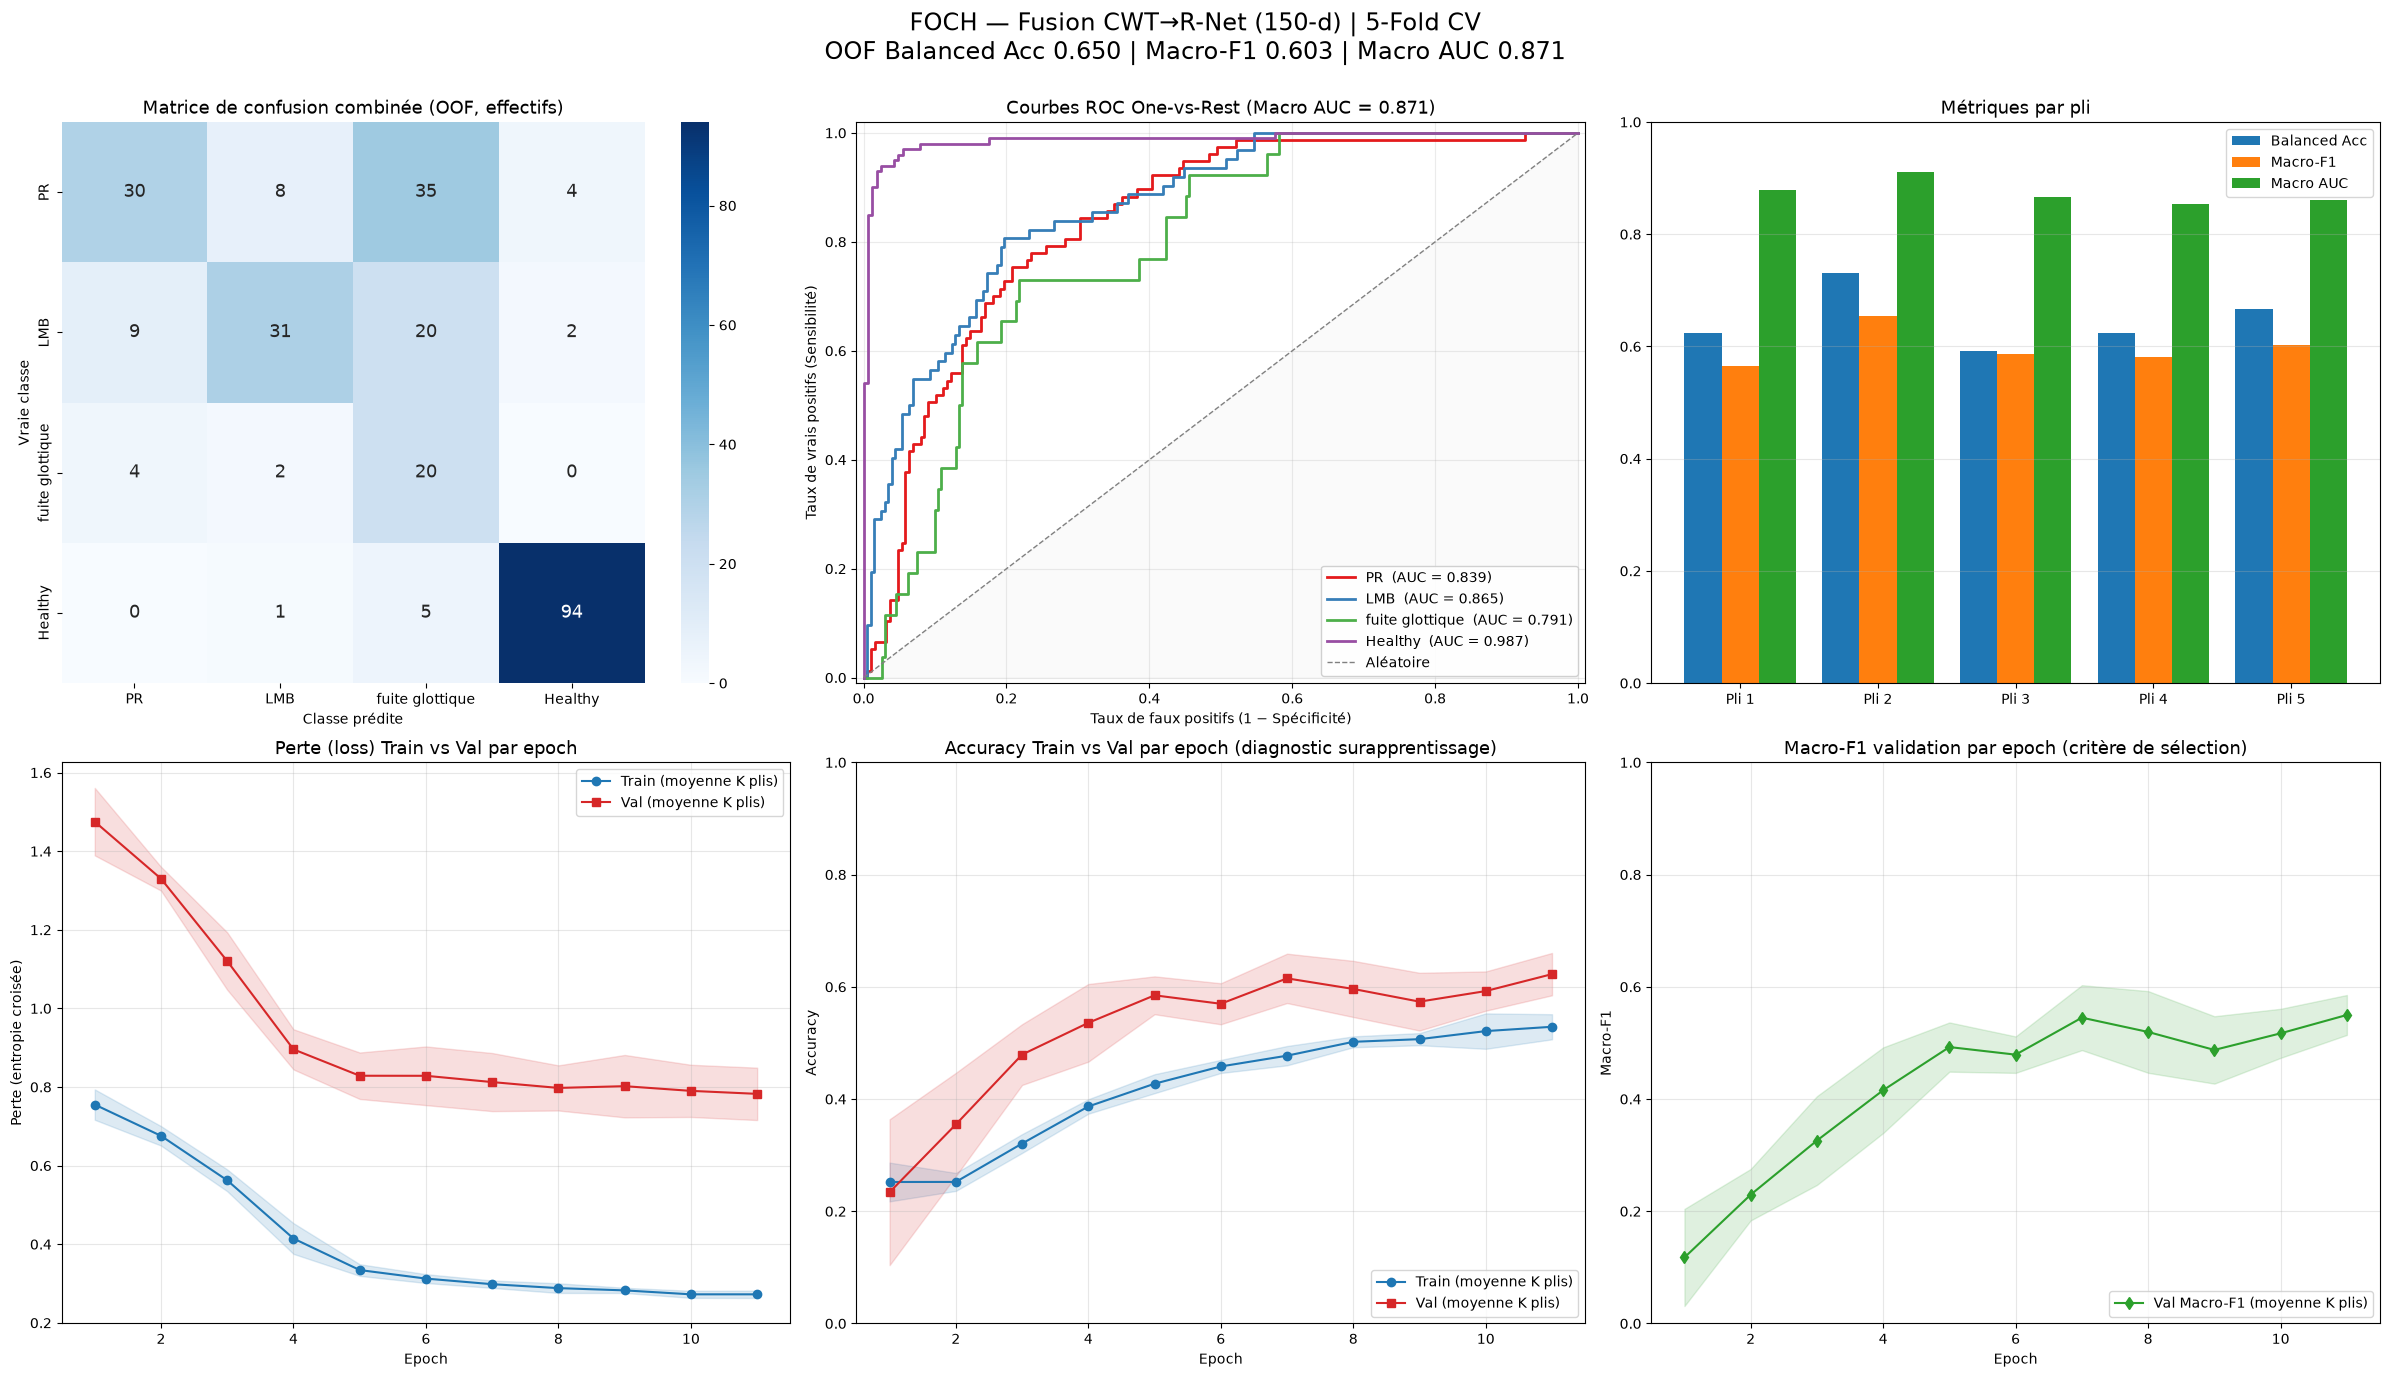


Artefacts sauvegardés dans C:/Users/AdminIA/Documents/models/.foch_métriques :
  • cwt_rnet_solo_kfold_aug_dashboard.png
  • cwt_rnet_solo_kfold_aug_metrics.json  (inclut matrices de confusion par pli, spécificité par classe, temps, checkpoints)
  • cwt_rnet_solo_kfold_aug_confusion.csv
  • cwt_rnet_solo_kfold_aug_fold_metrics.csv


In [11]:
# ═══════════════════════════════════════════════════════════════════════════
# Cellule 8 — Évaluation agrégée out-of-fold (K-Fold) + tableau de bord
# ═══════════════════════════════════════════════════════════════════════════
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc as sk_auc)
from sklearn.preprocessing import label_binarize

assert (oof_labels >= 0).all(), "Des enregistrements n'ont pas été évalués !"

# ── Métriques agrégées ────────────────────────────────────────────────────────
print('Rapport de classification agrégé (out-of-fold) :')
print('\n' + classification_report(oof_labels, oof_preds, labels=labels_idx,
                                    target_names=CLASSES, digits=3, zero_division=0))
oof_bal = balanced_accuracy_score(oof_labels, oof_preds)
oof_mf1 = f1_score(oof_labels, oof_preds, average='macro', zero_division=0)
try:
    oof_auc = roc_auc_score(oof_labels, oof_probs, multi_class='ovr',
                            average='macro', labels=labels_idx)
except ValueError:
    oof_auc = float('nan')

mean_bal, std_bal = fold_df['balanced_accuracy'].mean(), fold_df['balanced_accuracy'].std()
mean_f1,  std_f1  = fold_df['macro_f1'].mean(),          fold_df['macro_f1'].std()
mean_auc, std_auc = fold_df['macro_auc_ovr'].mean(),     fold_df['macro_auc_ovr'].std()
print(f'OOF global        — Balanced Acc {oof_bal:.4f} | Macro-F1 {oof_mf1:.4f} | Macro AUC {oof_auc:.4f}')
print(f'Moyenne par pli   — Balanced Acc {mean_bal:.4f}±{std_bal:.4f} | '
      f'Macro-F1 {mean_f1:.4f}±{std_f1:.4f} | Macro AUC {mean_auc:.4f}±{std_auc:.4f}')

# ── Titre dynamique : reflète le preset réellement actif ──────────────────────
_arch_names = []
if WAVLM_VARIANT:   _arch_names.append(f'WavLM-{WAVLM_VARIANT.replace("_", "-")}')
if USE_PANTAGRUEL:  _arch_names.append(f'Pantagruel-14K ({PANTAGRUEL_EMB_DIM}-d)')
if USE_RESIDUAL:    _arch_names.append(f'Résidu-Vocos×{N_RESIDUAL_FEATURES}→{RESIDUAL_PROJ_DIM}')
if USE_CWT_CNN:     _arch_names.append(f'CWT→R-Net ({RNET_EMB_DIM}-d)')
_arch_txt = ' + '.join(_arch_names) if _arch_names else BACKBONE

# ── ROC par classe (One-vs-Rest) ──────────────────────────────────────────────
oof_labels_bin = label_binarize(oof_labels, classes=labels_idx)   # (n, 4)

# ── Sensibilité / spécificité par classe (lecture clinique directe) ──────────
# La sensibilité (= rappel) est déjà dans `report_dict` (plus bas) ; la
# spécificité n'apparaît PAS dans classification_report — calculée ici
# explicitement à partir de la matrice de confusion combinée (One-vs-Rest par
# classe : TN/(TN+FP) sur les lignes/colonnes autres que la classe i).
cm = confusion_matrix(oof_labels, oof_preds, labels=labels_idx)
per_class_specificity = {}
for _i, _cls in enumerate(CLASSES):
    _tp = cm[_i, _i]
    _fn = cm[_i, :].sum() - _tp
    _fp = cm[:, _i].sum() - _tp
    _tn = cm.sum() - _tp - _fn - _fp
    per_class_specificity[_cls] = float(_tn / (_tn + _fp)) if (_tn + _fp) > 0 else float('nan')
print('\nSpécificité par classe (OOF, One-vs-Rest) :')
for _cls, _spec in per_class_specificity.items():
    print(f'  {_cls:<16} : {_spec:.3f}')

# ── Matrices de confusion PAR PLI (en plus de la matrice combinée OOF) ───────
# Chaque pli est reconstruit depuis `folds` (Cellule 5) + les conteneurs OOF
# (Cellule 7, remplis dans l'ordre des indices de validation) : aucune
# nécessité de les avoir stockées pendant la boucle K-Fold elle-même.
confusion_matrix_per_fold = []
for _fold_i, (_tr_idx, _va_idx) in enumerate(folds):
    _cm_fold = confusion_matrix(oof_labels[_va_idx], oof_preds[_va_idx], labels=labels_idx)
    confusion_matrix_per_fold.append(_cm_fold.tolist())

# ── Tableau de bord 2×3 ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
fig.suptitle(f'FOCH — Fusion {_arch_txt} | {K_FOLDS}-Fold CV\n'
             f'OOF Balanced Acc {oof_bal:.3f} | Macro-F1 {oof_mf1:.3f} | Macro AUC {oof_auc:.3f}',
             fontsize=17)

# ── [0, 0] Matrice de confusion (effectifs bruts) ─────────────────────────────
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=CLASSES, yticklabels=CLASSES, annot_kws={'size': 13})
axes[0, 0].set_title('Matrice de confusion combinée (OOF, effectifs)', fontsize=13)
axes[0, 0].set_ylabel('Vraie classe')
axes[0, 0].set_xlabel('Classe prédite')

# ── [0, 1] Courbes ROC OvR par classe ────────────────────────────────────────
_colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']   # rouge, bleu, vert, violet
for i, (cls, col) in enumerate(zip(CLASSES, _colors)):
    fpr, tpr, _ = roc_curve(oof_labels_bin[:, i], oof_probs[:, i])
    auc_i = sk_auc(fpr, tpr)
    axes[0, 1].plot(fpr, tpr, color=col, lw=2, label=f'{cls}  (AUC = {auc_i:.3f})')

axes[0, 1].plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--', label='Aléatoire')
axes[0, 1].fill_between([0, 1], [0, 1], alpha=0.04, color='grey')
axes[0, 1].set_xlim([-0.01, 1.01]); axes[0, 1].set_ylim([-0.01, 1.02])
axes[0, 1].set_xlabel('Taux de faux positifs (1 − Spécificité)')
axes[0, 1].set_ylabel('Taux de vrais positifs (Sensibilité)')
axes[0, 1].set_title(f'Courbes ROC One-vs-Rest (Macro AUC = {oof_auc:.3f})', fontsize=13)
axes[0, 1].legend(loc='lower right', framealpha=0.9)
axes[0, 1].grid(True, alpha=0.25)

# ── [0, 2] Métriques par pli ──────────────────────────────────────────────────
x = np.arange(K_FOLDS); w = 0.27
axes[0, 2].bar(x - w, fold_df['balanced_accuracy'], w, label='Balanced Acc')
axes[0, 2].bar(x,     fold_df['macro_f1'],          w, label='Macro-F1')
axes[0, 2].bar(x + w, fold_df['macro_auc_ovr'],     w, label='Macro AUC')
axes[0, 2].set_title('Métriques par pli', fontsize=13)
axes[0, 2].set_xticks(x)
axes[0, 2].set_xticklabels([f'Pli {i+1}' for i in range(K_FOLDS)])
axes[0, 2].set_ylim(0, 1)
axes[0, 2].legend()
axes[0, 2].grid(True, axis='y', alpha=0.3)

# ── [1, 0] Perte (loss) Train vs Val par epoch ────────────────────────────────
assert 'fold_train_loss' in globals() and len(fold_train_loss), \
    "fold_train_loss manquant — réexécutez la Cellule 7 (boucle K-Fold) pour régénérer l'historique."
min_ep_loss = min(min(len(h) for h in fold_train_loss),
                   min(len(h) for h in fold_curves))
tr_loss = np.array([h[:min_ep_loss] for h in fold_train_loss])   # (K, min_ep)
va_loss = np.array([h[:min_ep_loss] for h in fold_curves])
ep_loss = np.arange(1, min_ep_loss + 1)
axes[1, 0].plot(ep_loss, tr_loss.mean(0), 'o-', color='#1f77b4', label='Train (moyenne K plis)')
axes[1, 0].fill_between(ep_loss, tr_loss.mean(0) - tr_loss.std(0), tr_loss.mean(0) + tr_loss.std(0),
                        color='#1f77b4', alpha=0.15)
axes[1, 0].plot(ep_loss, va_loss.mean(0), 's-', color='#d62728', label='Val (moyenne K plis)')
axes[1, 0].fill_between(ep_loss, va_loss.mean(0) - va_loss.std(0), va_loss.mean(0) + va_loss.std(0),
                        color='#d62728', alpha=0.15)
axes[1, 0].set_title('Perte (loss) Train vs Val par epoch', fontsize=13)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Perte (entropie croisée)')
axes[1, 0].legend(loc='upper right')
axes[1, 0].grid(True, alpha=0.3)

# ── [1, 1] Diagnostic de surapprentissage : Train vs Val accuracy / epoch ─────
# Lecture particulièrement importante ici : R-Net (branche D) est entraîné from
# scratch (Cellule 6/7) — un écart Train/Val qui se creuse tôt serait le signe
# que sa capacité (~346 k paramètres) reste malgré tout trop grande pour ~300
# échantillons, ou que RNET_LR/RNET_WEIGHT_DECAY (Cellule 1) doivent être revus.
assert 'fold_train_acc' in globals() and 'fold_val_acc' in globals() \
        and len(fold_train_acc) and len(fold_val_acc), \
    "fold_train_acc/fold_val_acc manquant — réexécutez la Cellule 7 (boucle K-Fold) pour régénérer l'historique."
min_ep = min(min(len(h) for h in fold_train_acc),
             min(len(h) for h in fold_val_acc))
tr = np.array([h[:min_ep] for h in fold_train_acc])   # (K, min_ep)
va = np.array([h[:min_ep] for h in fold_val_acc])
ep = np.arange(1, min_ep + 1)
axes[1, 1].plot(ep, tr.mean(0), 'o-', color='#1f77b4', label='Train (moyenne K plis)')
axes[1, 1].fill_between(ep, tr.mean(0) - tr.std(0), tr.mean(0) + tr.std(0),
                        color='#1f77b4', alpha=0.15)
axes[1, 1].plot(ep, va.mean(0), 's-', color='#d62728', label='Val (moyenne K plis)')
axes[1, 1].fill_between(ep, va.mean(0) - va.std(0), va.mean(0) + va.std(0),
                        color='#d62728', alpha=0.15)
axes[1, 1].set_title('Accuracy Train vs Val par epoch (diagnostic surapprentissage)', fontsize=13)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].legend(loc='lower right')
axes[1, 1].grid(True, alpha=0.3)

# ── [1, 2] Macro-F1 de validation par epoch (critère de sélection) ────────────
min_ep_f1 = min(len(h) for h in fold_val_f1)
vf1 = np.array([h[:min_ep_f1] for h in fold_val_f1])
ep_f1 = np.arange(1, min_ep_f1 + 1)
axes[1, 2].plot(ep_f1, vf1.mean(0), 'd-', color='#2ca02c', label='Val Macro-F1 (moyenne K plis)')
axes[1, 2].fill_between(ep_f1, vf1.mean(0) - vf1.std(0), vf1.mean(0) + vf1.std(0),
                        color='#2ca02c', alpha=0.15)
axes[1, 2].set_title('Macro-F1 validation par epoch (critère de sélection)', fontsize=13)
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('Macro-F1')
axes[1, 2].set_ylim(0, 1)
axes[1, 2].legend(loc='lower right')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(top=0.90)
fig_path = os.path.join(METRICS_DIR, f'{RUN_NAME}_dashboard.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

# ── Sauvegarde des artefacts ──────────────────────────────────────────────────
report_dict = classification_report(oof_labels, oof_preds, labels=labels_idx,
                                     target_names=CLASSES, output_dict=True, zero_division=0)
metrics = {
    'run_name':               RUN_NAME,
    'architecture':           _arch_txt,
    'preset':                 BACKBONE,
    'branches':               {'wavlm': WAVLM_VARIANT, 'pantagruel': USE_PANTAGRUEL, 'residual': USE_RESIDUAL, 'cwt_cnn': USE_CWT_CNN},
    'fusion_dim':             int(FUSION_DIM_EXPECTED),
    'pantagruel_emb_dim':     int(PANTAGRUEL_EMB_DIM),
    'cwt_wavelet':            CWT_WAVELET if USE_CWT_CNN else None,
    'cwt_freq_range_hz':      [CWT_FREQ_MIN, CWT_FREQ_MAX] if USE_CWT_CNN else None,
    'cwt_n_scales':           CWT_N_SCALES if USE_CWT_CNN else None,
    'onset_sr_hz':            ONSET_SR if USE_CWT_CNN else None,
    'onset_window_s':         ONSET_WINDOW_S if USE_CWT_CNN else None,
    'onset_len_samples':      ONSET_LEN if USE_CWT_CNN else None,
    'rnet_architecture':      {
        'conv_channels': RNET_CONV_CHANNELS, 'kernel': RNET_KERNEL, 'stride': RNET_STRIDE,
        'padding': RNET_PADDING, 'emb_dim': RNET_EMB_DIM, 'out_spatial': list(RNET_OUT_SPATIAL),
        'lr': RNET_LR, 'weight_decay': RNET_WEIGHT_DECAY, 'trainable': True,
    } if USE_CWT_CNN else None,
    'encoders_frozen':        {'wavlm': True, 'pantagruel': True, 'rnet': False},
    'residual_features':      list(RESIDUAL_FEATURES) if USE_RESIDUAL else [],
    'residual_proj_dim':      RESIDUAL_PROJ_DIM if USE_RESIDUAL else 0,
    'residual_stats_per_fold': fold_residual_stats,
    'cv':                     f'StratifiedKFold(n_splits={K_FOLDS})',
    'oof_balanced_accuracy':  oof_bal,
    'oof_macro_f1':           oof_mf1,
    'oof_macro_auc_ovr':      oof_auc,
    'mean_balanced_accuracy': mean_bal, 'std_balanced_accuracy': std_bal,
    'mean_macro_f1':          mean_f1,  'std_macro_f1':          std_f1,
    'mean_macro_auc_ovr':     mean_auc, 'std_macro_auc_ovr':     std_auc,
    'per_fold':               fold_rows,
    'per_class_oof':          report_dict,
    'per_class_specificity':  per_class_specificity,
    'confusion_matrix_oof':   cm.tolist(),
    'confusion_matrix_per_fold': confusion_matrix_per_fold,
    'checkpoint_paths':       fold_checkpoint_paths,
    'training_time_seconds':  TOTAL_TRAIN_TIME_S,
    'classes':                CLASSES,
    'n_total':                int(len(df)),
}
with open(os.path.join(METRICS_DIR, f'{RUN_NAME}_metrics.json'), 'w', encoding='utf-8') as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2, default=float)
np.savetxt(os.path.join(METRICS_DIR, f'{RUN_NAME}_confusion.csv'), cm, fmt='%d', delimiter=',')
fold_df.to_csv(os.path.join(METRICS_DIR, f'{RUN_NAME}_fold_metrics.csv'), index=False)

print(f'\nArtefacts sauvegardés dans {METRICS_DIR} :')
print(f'  • {RUN_NAME}_dashboard.png')
print(f'  • {RUN_NAME}_metrics.json  (inclut matrices de confusion par pli, spécificité par classe, temps, checkpoints)')
print(f'  • {RUN_NAME}_confusion.csv')
print(f'  • {RUN_NAME}_fold_metrics.csv')


### 8b. Journal persistant des runs (branches, augmentations, métriques)

La Cellule 8 écrit `{RUN_NAME}_metrics.json` / `_fold_metrics.csv` : un seul fichier par preset, écrasé à chaque nouvelle exécution du même `BACKBONE`. Utile pour l'inspection d'un run précis, mais rien ne survit d'une exécution à l'autre pour comparer les presets entre eux.

Cette cellule reprend **telle quelle** la mécanique de `10_0_foch_test_pantagruel.ipynb` (Cellule 8b) : elle ajoute **une ligne par exécution** à un CSV unique et persistant (`runs_log.csv`, dans le dossier de ce notebook) — preset de branches actives, types d'augmentation activés, hyperparamètres, métriques OOF, **temps d'entraînement total** et **architecture R-Net**. Exécuter cette cellule **après** la Cellule 8 (elle lit `oof_bal`, `mean_f1`, `fold_df`, `TOTAL_TRAIN_TIME_S`, etc. déjà calculés). Le fichier n'est jamais écrasé : chaque exécution relit le CSV existant, concatène la nouvelle ligne, puis réécrit l'ensemble (alignement par nom de colonne, `sort=False`) — ce qui tolère l'ajout futur d'une colonne sans casser l'historique déjà journalisé.

> `runs_log.csv` est propre à ce dossier (`cwt_test/`) — indépendant de celui de `pantagruel/`, qui ne connaît pas les colonnes `cwt_*`/`rnet_*`/`onset_*` de ce notebook.


In [12]:
# ══════════════════════════════════════════════════════════════════════════════════
# Cellule 8b — Journal persistant des runs (branches, augmentations, métriques)
# ══════════════════════════════════════════════════════════════════════════════════
import datetime
import os
from pathlib import Path

# ── Résolution du dossier du notebook (même dossier que ce .ipynb) ─────────────
def _resolve_notebook_dir():
    candidates = [Path.cwd(), Path.cwd() / 'cwt_test', Path.cwd().parent / 'cwt_test']
    candidates.append(Path(r'C:/Users/AdminIA/Desktop/Classif_Aug/cwt_test'))
    for candidate in candidates:
        if (candidate / '13_0_foch_test_cwt_rnet.ipynb').exists():
            return candidate.resolve()
    return Path.cwd().resolve()


NOTEBOOK_DIR = _resolve_notebook_dir()
RUNS_LOG_PATH = os.path.join(str(NOTEBOOK_DIR), 'runs_log.csv')

# ── Une ligne = un run ─────────────────────────────────────────────────────────────────────────────
run_record = {
    'run_id':                  None,   # rempli plus bas (compteur du journal)
    'timestamp':               datetime.datetime.now().isoformat(timespec='seconds'),
    'run_name':                RUN_NAME,
    'preset':                  BACKBONE,
    'model_name':              'R-Net (Wu, 2020)' if USE_CWT_CNN else None,
    'wavlm_variant':           WAVLM_VARIANT,
    'use_pantagruel':          USE_PANTAGRUEL,
    'use_residual':            USE_RESIDUAL,
    'use_cwt_rnet':            USE_CWT_CNN,
    'fusion_dim':              int(FUSION_DIM_EXPECTED),
    'aug_types_enabled':       '+'.join(sorted(AUG_TYPES_ENABLED)) if AUG_TYPES_ENABLED else 'aucune',
    'finetune_scope':          'tete_fusion+proj_residu+rnet (wavlm/pantagruel geles)',
    'k_folds':                 K_FOLDS,
    'max_len_s':               MAX_LEN_S,
    'batch_size':              BATCH_SIZE,
    'accum_steps':             ACCUM_STEPS,
    'effective_batch':         BATCH_SIZE * ACCUM_STEPS,
    'epochs_max':              EPOCHS,
    'lr':                      LR,
    'weight_decay':            WEIGHT_DECAY,
    'dropout':                 DROPOUT,
    'hidden_dim':              HIDDEN_DIM,
    'input_dropout':           INPUT_DROPOUT,
    'focal_gamma':             FOCAL_GAMMA,
    # ── Hyperparamètres et géométrie propres à la branche CWT → R-Net ────────
    'cwt_wavelet':             CWT_WAVELET if USE_CWT_CNN else None,
    'cwt_n_scales':            CWT_N_SCALES if USE_CWT_CNN else None,
    'onset_sr_hz':             ONSET_SR if USE_CWT_CNN else None,
    'onset_window_s':          ONSET_WINDOW_S if USE_CWT_CNN else None,
    'onset_len_samples':       ONSET_LEN if USE_CWT_CNN else None,
    'rnet_conv_channels':      '-'.join(map(str, RNET_CONV_CHANNELS)) if USE_CWT_CNN else None,
    'rnet_emb_dim':            RNET_EMB_DIM if USE_CWT_CNN else None,
    'rnet_lr':                 RNET_LR if USE_CWT_CNN else None,
    'rnet_weight_decay':       RNET_WEIGHT_DECAY if USE_CWT_CNN else None,
    'input_dim':               f'(3, {CWT_N_SCALES}, {ONSET_LEN})' if USE_CWT_CNN else None,
    'n_total':                 int(len(df)),
    'n_healthy_target':        N_HEALTHY,
    'oof_balanced_accuracy':   oof_bal,
    'oof_macro_f1':            oof_mf1,
    'oof_macro_auc_ovr':       oof_auc,
    'mean_balanced_accuracy':  mean_bal, 'std_balanced_accuracy': std_bal,
    'mean_macro_f1':           mean_f1,  'std_macro_f1':          std_f1,
    'mean_macro_auc_ovr':      mean_auc, 'std_macro_auc_ovr':     std_auc,
    'training_time_seconds':   TOTAL_TRAIN_TIME_S,
    'metrics_json_path':       os.path.join(METRICS_DIR, f'{RUN_NAME}_metrics.json'),
    'notes':                   '',   # champ libre — à compléter à la main après coup si besoin
}

new_row = pd.DataFrame([run_record])

# ── Lecture-concaténation-réécriture, jamais un append brut ────────────────
if os.path.isfile(RUNS_LOG_PATH):
    runs_log = pd.read_csv(RUNS_LOG_PATH)
    if 'run_id' not in runs_log.columns:
        runs_log['run_id'] = range(1, len(runs_log) + 1)
    next_run_id = int(runs_log['run_id'].max()) + 1 if len(runs_log) else 1
    new_row['run_id'] = next_run_id
    runs_log = pd.concat([runs_log, new_row], ignore_index=True, sort=False)
else:
    new_row['run_id'] = 1
    runs_log = new_row

runs_log.to_csv(RUNS_LOG_PATH, index=False)

print(f"Run \"{RUN_NAME}\" (id {int(new_row['run_id'].iloc[0])}) ajouté au journal "
      f"— {len(runs_log)} run(s) au total → {RUNS_LOG_PATH}")
runs_log[['run_id', 'timestamp', 'run_name', 'preset', 'aug_types_enabled',
          'oof_balanced_accuracy', 'oof_macro_f1', 'oof_macro_auc_ovr',
          'training_time_seconds']].tail(5)


Run "cwt_rnet_solo_kfold_aug" (id 2) ajouté au journal — 2 run(s) au total → C:\Users\AdminIA\Desktop\Classif_Aug\cwt_test\runs_log.csv


,run_id,timestamp,run_name,preset,aug_types_enabled,oof_balanced_accuracy,oof_macro_f1,oof_macro_auc_ovr,training_time_seconds
0,1,2026-09-03T13:24:36,wavlm_bp_cwt_rnet_kfold_aug,wavlm_bp_cwt_rnet,signal+vc,0.643834,0.618767,0.865873,1496.987454
1,2,2026-09-03T13:41:16,cwt_rnet_solo_kfold_aug,cwt_rnet_solo,signal+vc,0.649710,0.603378,0.870554,796.938920


## 9. Synthèse et prochaines étapes

**Ce que fait ce notebook.**

- **Classifieur quadri-branche configurable**, protocole d'évaluation inchangé depuis `10_0_foch_test_pantagruel.ipynb` / `11_0_foch_test_cwt_dinov2.ipynb` / `12_0_foch_test_cwt_resnet.ipynb`.
- **Préset par défaut : `wavlm_bp_cwt_rnet`** — WavLM Base-Plus + scalogramme CWT → R-Net, sans Pantagruel ni résidu vocodeur. Tous les presets à trois et quatre branches restent disponibles.
- **Branche D — CWT → R-Net (Wu, 2020), remplace le ResNet ImageNet gelé de `12_0_foch_test_cwt_resnet.ipynb`.** Architecture légère à 4 couches convolutives **à stride** (30/50/100/150 filtres, noyau 4×4, sans pooling explicite), **entraînée from scratch** — pas de transfert d'apprentissage, à la différence des trois notebooks précédents de la lignée CWT.
- **Fenêtre d'entrée spécifique à la branche D : l'attaque de la voyelle, pas l'enregistrement entier.** 120 ms à 25 kHz (`ONSET_SR`/`ONSET_WINDOW_S`/`ONSET_LEN`, Cellule 1) — spécification Wu (2020) — dérivée de la MÊME lecture disque que les branches A/B/C (un seul accès fichier, deux ré-échantillonnages).
- **Fine-tuning étendu à R-Net** : WavLM et Pantagruel restent intégralement gelés (comme `10_0`-`12_0`), mais **R-Net est entraînable** — seule branche profonde de ce notebook à participer à la rétropropagation. L'optimiseur (Cellule 7) reçoit en conséquence **deux groupes de paramètres** à des taux d'apprentissage distincts (`LR`/`WEIGHT_DECAY` pour la tête+résidu, `RNET_LR`/`RNET_WEIGHT_DECAY` pour R-Net).
- **Géométrie validée deux fois, pas résolue depuis un checkpoint externe** : `RNET_EMB_DIM` est une constante d'architecture (pas de checkpoint dont la dimension pourrait diverger) ; c'est la **géométrie spatiale** de l'empilement à stride qui est vérifiée — une fois arithmétiquement en Cellule 1 (avant tout calcul CWT), une seconde fois sur un scalogramme réel en Cellule 4c.
- **Validation croisée sans fuite**, inchangée. La branche scalogramme n'a pas de statistique de pli à recalculer (normalisation fixe `(x−0.5)/0.5`).
- **Journal de run étendu** : matrices de confusion par pli, sensibilité/spécificité par classe, temps d'entraînement total et chemins de checkpoints désormais dans `{RUN_NAME}_metrics.json` (Cellule 8) ; `runs_log.csv` (Cellule 8b, mécanique reprise de `10_0_foch_test_pantagruel.ipynb`) journalise en plus les hyperparamètres R-Net et le temps d'entraînement par run.

**Pistes d'amélioration ultérieures :**
1. **Comparer directement aux presets équivalents de `12_0_foch_test_cwt_resnet.ipynb`** (`wavlm_bp_cwt_resnet` vs `wavlm_bp_cwt_rnet`, même graine, mêmes plis) — c'est la mesure directe de l'hypothèse posée par ce notebook : un CNN léger entraîné from scratch sur la fenêtre d'attaque peut-il égaler/dépasser un ResNet ImageNet gelé sur l'enregistrement entier ?
2. **Exécuter la grille d'ablation propre à ce notebook** (`wavlm_bp_solo`, `cwt_rnet_solo`, `wavlm_bp_cwt_rnet`, puis les presets incluant Pantagruel/résidu) — même graine, mêmes plis.
3. **Élargir la fenêtre d'attaque au-delà de 120 ms** — la spécification de Wu (2020) est reprise telle quelle ; rien n'indique qu'elle soit optimale pour CE corpus (voyelles soutenues FOCH/SVD plutôt que le matériel d'origine de la thèse). `ONSET_WINDOW_S` est isolé en Cellule 1 pour ce test.
4. **Vraie ondelette de Morse** (`ssqueezepy` ou équivalent) plutôt que Morlet complexe — PyWavelets ne l'implémente pas nativement (cf. encadré Cellule 4) ; question ouverte non tranchée ici.
5. **Comparer `RNET_LR`/`RNET_WEIGHT_DECAY`** à une grille plus large — les valeurs de la thèse de Wu (3e-5 / 5e-5) sont reprises telles quelles, non retunées pour ce corpus ni cette architecture de fusion.
6. **Mise en cache disque des sorties WavLM/Pantagruel gelées** — idée déjà notée dans les notebooks précédents, toujours valable.
7. **Ensembling** des K modèles de plis à l'inférence.
8. **Audit qualité** des doublons d'homonymes (`Last_Name`) via `patient_id`.

> ⚠️ **Rappel d'exécution** — cellules à exécuter **dans l'ordre** (1 → 8, plus 4b, 4c et 8b). WavLM, Pantagruel et Vocos sont chargés **localement** (`HF_HUB_OFFLINE=1`). **R-Net ne dépend d'aucun réseau** (initialisation aléatoire). La branche CWT requiert `pywt`. La Cellule 7 entraîne **K = 5 modèles**, avec R-Net entraînable en plus de la tête — le temps par pli est chronométré et journalisé.

## Journal des modifications

- **2026-09-03 — Remplacement de la branche D : ResNet ImageNet gelé (`12_0_foch_test_cwt_resnet.ipynb`) → R-Net entraîné from scratch (Wu, 2020), preset par défaut renommé `wavlm_bp_cwt_rnet`.**
  - **Pourquoi** : tester un troisième pari architectural pour la branche scalogramme, après le ViT gelé (`11_0`, DINOv2-Large) et le CNN gelé (`12_0`, ResNet) — cette fois un CNN entraîné **directement** sur le corpus, sans transfert d'apprentissage, avec une architecture délibérément minimaliste (~346 k paramètres) pour limiter le surapprentissage sur ~300 échantillons.
  - **Fenêtre d'entrée changée en même temps que le backbone** : `12_0` faisait porter le scalogramme sur l'enregistrement entier (4 s/16 kHz, comme les branches A/B/C) ; ce notebook le restreint à la fenêtre d'attaque (120 ms/25 kHz) — spécification de Wu (2020), pas un choix indépendant. Conséquence directe en Cellule 4 : le Dataset dérive désormais DEUX vues rééchantillonnées d'un même accès disque, plutôt qu'une vue unique partagée par les quatre branches.
  - **Passage de gelé à entraînable pour la branche D** : R-Net n'a pas de checkpoint pré-entraîné (ni ImageNet, ni audio) — contrairement à `11_0`/`12_0`, il n'y a rien à geler. Répercussions : `trainable_state_dict()` (Cellule 6) inclut désormais R-Net ; l'optimiseur (Cellule 7/6b) utilise deux groupes de paramètres à LR distincts ; le garde-fou de gel (Cellule 6) vérifie désormais l'ABSENCE de gel sur R-Net plutôt que sa présence.
  - **Suppression de la dépendance torchvision** : plus de `TORCH_HOME`, plus de `RESNET_VARIANT`/`weights.transforms()` — R-Net est un `nn.Module` pur, sans checkpoint externe à résoudre. `RNET_EMB_DIM` devient une constante d'architecture ; la discipline « jamais écrit en dur » se reporte sur la validation de la géométrie spatiale de l'empilement à stride (Cellule 1, puis Cellule 4c sur un scalogramme réel).
  - **Redimensionnement et normalisation ImageNet retirés** : la fenêtre d'attaque étant de longueur fixe, le scalogramme a déjà une forme constante (pas de redimensionnement bilinéaire nécessaire) ; la normalisation devient un simple recadrage fixe `(x−0.5)/0.5` (pas de statistiques de checkpoint externe à respecter, R-Net n'en ayant aucun).
  - **Journal de run étendu (Cellule 8/8b)** : matrices de confusion par pli, sensibilité/spécificité par classe, temps d'entraînement total, chemins de checkpoints — ajoutés au JSON (Cellule 8) et à `runs_log.csv` (Cellule 8b, mécanique reprise telle quelle de `10_0_foch_test_pantagruel.ipynb`, étendue avec les colonnes `cwt_*`/`rnet_*`/`onset_*`/`training_time_seconds`).
  - **Renommage systématique** `USE_CWT_CNN` conservé (générique, toujours vrai pour ce backbone) ; `RESNET_VARIANT`/`RESNET_EMB_DIM`/`RESNET_IMG_SIZE`/`TORCH_HOME` → retirés ; `RNET_CONV_CHANNELS`/`RNET_KERNEL`/`RNET_STRIDE`/`RNET_PADDING`/`RNET_EMB_DIM`/`RNET_LR`/`RNET_WEIGHT_DECAY`/`ONSET_SR`/`ONSET_WINDOW_S`/`ONSET_LEN` → ajoutés ; presets `*_cwt_resnet`→`*_cwt_rnet`, `self.resnet`→`self.rnet` (donc **nouveau** `RUN_NAME` par preset — aucun écrasement des checkpoints/métriques de `12_0_foch_test_cwt_resnet.ipynb`).
  - **Cellule 4c, boucle K-Fold (Cellule 7) et évaluation (Cellule 8)** : structure conservée, adaptées à la fenêtre d'attaque et aux deux groupes de paramètres.

  **Questions ouvertes (nouvelles, spécifiques à cette variante) :**
  - **R-Net vs ResNet gelé non comparé empiriquement sur ce corpus** — c'est la question de fond que ce notebook pose sans y répondre ; cf. piste d'amélioration n°1.
  - **Fenêtre de 120 ms non ré-évaluée pour ce corpus** — reprise telle quelle de la spécification de Wu (2020) ; cf. piste d'amélioration n°3.
  - **Ondelette de Morse non disponible dans PyWavelets** — Morlet complexe substituée (propriété analytique partagée) ; cf. encadré Cellule 4 et piste d'amélioration n°4.
  - **`RNET_LR`/`RNET_WEIGHT_DECAY` non retunés** pour cette architecture de fusion ni ce corpus — valeurs de la thèse reprises telles quelles ; cf. piste d'amélioration n°5.
  - **Valeur clinique réelle non établie**, comme pour les variantes ViT/ResNet.
